<a href="https://colab.research.google.com/github/alanagadelha/DeepLearning_AntarticaWork/blob/main/SSCAD2025_Previs%C3%A3o_de_Temperatura_e_Vento_na_Ant%C3%A1rtica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup das configurações

In [4]:
!pip install nvidia-ml-py3 psutil matplotlib
!pip install ydata-profiling -q

  Preparing metadata (setup.py) ... done
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19172 sha256=9e4ae74031e3f5467d5474ed5dafedbff5fe0f4f52f03c036399a811e5b8c176
  Stored in directory: /root/.cache/pip/wheels/6e/65/79/33dee66cba26e8204801916dfee7481bccfd22905ebb841fe5
Successfully built nvidia-ml-py3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.0 MB/s eta 0:00:00


In [5]:
!cat /proc/meminfo | grep MemTotal
!cat /proc/cpuinfo | grep processor | wc -l
!cat /etc/os-release
!df -h

MemTotal:       13289424 kB
2
PRETTY_NAME="Ubuntu 22.04.4 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.4 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   40G   74G  35% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.2G  775M  61% /usr/sbin/docker-init
tmpfs           6.4G  556K  6.4G   1% /var/colab
/dev/sda1        74G   42G   33G  57% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware


In [6]:
!nvidia-smi

Sun Sep 14 16:12:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
usuario='Ygor'

arquivo_metar = 'metar_frei_20100101_20250630-novoteste.csv'
endpoint = 'https://ygor.ml/uff/sscad2025'

modo_execucao = 'Treinamento' # e.g: 'Treinamento' ou 'Visualização'
modo_hardware = 'GPU'

lista_modelos = {
    'Linear': 'Linear_01-08-2025_031423Z.keras',
    'mlp': 'mlp_01-08-2025_031717Z.keras',
    'mlp2': 'mlp2_01-08-2025_032015Z.keras',
    'multiple-input-step': 'multiple-input-step_01-08-2025_032355Z.keras',
    'multiple-input-step-2': 'multiple-input-step-2_01-08-2025_032819Z.keras',
    'cnn': 'cnn_01-08-2025_033020Z.keras',
    'LSTM': 'LSTM_01-08-2025_034323Z.keras',
    'BiLSTM': 'BiLSTM_01-08-2025_035824Z.keras'
}

tempos_treinamento = {} # Treinamento
tempos_validacao = {}  # Validacao
tempos_teste = {} # Teste / Inferência

val_performance = {}
performance = {}

In [8]:
!wget -O {arquivo_metar} {endpoint}/{arquivo_metar}

--2025-09-14 16:12:20--  https://ygor.ml/uff/sscad2025/metar_frei_20100101_20250630-novoteste.csv
Resolving ygor.ml (ygor.ml)... 177.73.233.43
Connecting to ygor.ml (ygor.ml)|177.73.233.43|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6316847 (6.0M) [text/csv]
Saving to: ‘metar_frei_20100101_20250630-novoteste.csv’

metar_frei_20100101 100%[===================>]   6.02M  1.90MB/s    in 3.2s    

2025-09-14 16:12:26 (1.90 MB/s) - ‘metar_frei_20100101_20250630-novoteste.csv’ saved [6316847/6316847]



In [9]:
if modo_execucao == 'Visualização':
  for key, value in lista_modelos.items():
    !wget {endpoint}/{value}

In [10]:
import time
import psutil
import matplotlib.pyplot as plt
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo, nvmlDeviceGetUtilizationRates
from tensorflow.keras.callbacks import Callback
import numpy as np
import datetime

# Lista global para armazenar todos os monitors criados
monitors = []

class ResourceMonitorCallback(Callback):
    def __init__(self, model_name='model', gpu_index=0, time_based=True):
        """Inicializa o monitor para um modelo específico.

        Args:
            model_name (str): Nome do modelo para identificação
            gpu_index (int): Índice da GPU a monitorar
            time_based (bool): Se True, gráficos serão por tempo; False para épocas
        """
        super().__init__()
        self.model_name = model_name
        self.time_based = time_based
        self.gpu_available = False

        try:
            nvmlInit()
            self.gpu_handle = nvmlDeviceGetHandleByIndex(gpu_index)
            self.gpu_available = True
        except Exception as e:
            print(f"AVISO: Monitoramento de GPU desativado. Erro: {e}")

        self.metrics = {
            'timestamps': [],
            'epochs': [],
            'gpu_mem_usage': [],
            'gpu_util': [],
            'cpu_usage': [],
            'ram_usage': []
        }
        monitors.append(self)  # Auto-registro na lista global

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        # Coleta métricas da GPU
        if self.gpu_available:
            try:
                mem_info = nvmlDeviceGetMemoryInfo(self.gpu_handle)
                util = nvmlDeviceGetUtilizationRates(self.gpu_handle)
                self.metrics['gpu_mem_usage'].append(mem_info.used / (1024**2))  # MB
                self.metrics['gpu_util'].append(util.gpu)  # %
            except Exception as e:
                print(f"Erro ao coletar métricas da GPU: {e}")
                self.metrics['gpu_mem_usage'].append(0)
                self.metrics['gpu_util'].append(0)

        # Coleta métricas da CPU/RAM
        self.metrics['cpu_usage'].append(psutil.cpu_percent(interval=0.1))  # %
        self.metrics['ram_usage'].append(psutil.virtual_memory().used / (1024**3))  # GB
        self.metrics['timestamps'].append(time.time() - self.start_time)  # s
        self.metrics['epochs'].append(epoch + 1)  # epoch começa em 0

    def plot_metrics(self, show=True, save_path=None):
        """Gera gráficos para este modelo específico."""
        if not self.metrics['epochs']:
            print("Nenhuma métrica disponível para plotar.")
            return

        plt.figure(figsize=(15, 10), num=f"Resource Usage - {self.model_name}")

        x_values = self.metrics['timestamps'] if self.time_based else self.metrics['epochs']
        x_label = 'Tempo (s)' if self.time_based else 'Época'

        # GPU Metrics
        if self.gpu_available and any(self.metrics['gpu_mem_usage']):
            plt.subplot(2, 2, 1)
            plt.plot(x_values, self.metrics['gpu_mem_usage'], 'b-')
            plt.title(f'{self.model_name} - Uso de Memória GPU')
            plt.ylabel('MB')
            plt.xlabel(x_label)
            plt.grid(True)

            plt.subplot(2, 2, 2)
            plt.plot(x_values, self.metrics['gpu_util'], 'r-')
            plt.title(f'{self.model_name} - Utilização GPU')
            plt.ylabel('%')
            plt.xlabel(x_label)
            plt.grid(True)

        # CPU/RAM Metrics
        plt.subplot(2, 2, 3)
        plt.plot(x_values, self.metrics['cpu_usage'], 'g-')
        plt.title(f'{self.model_name} - Utilização CPU')
        plt.ylabel('%')
        plt.xlabel(x_label)
        plt.grid(True)

        plt.subplot(2, 2, 4)
        plt.plot(x_values, self.metrics['ram_usage'], 'm-')
        plt.title(f'{self.model_name} - Uso de Memória RAM')
        plt.ylabel('GB')
        plt.xlabel(x_label)
        plt.grid(True)

        plt.suptitle(f'Monitoramento de Recursos - {self.model_name}', y=1.02)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Gráfico salvo em: {save_path}")
        if show:
            plt.show()

def plot_combined_metrics(metrics=None, time_based=True, figsize=(15, 10)):
    """Plota métricas comparativas para todos os modelos monitorados.

    Args:
        metrics (list): Lista de métricas para plotar (padrão: todas principais)
        time_based (bool): Se True, eixo X como tempo; False para épocas
        figsize (tuple): Tamanho da figura
    """
    if not monitors:
        print("Nenhum modelo monitorado encontrado.")
        return

    if not metrics:
        metrics = ['cpu_usage', 'ram_usage']
        if monitors[0].gpu_available:
            metrics.extend(['gpu_util', 'gpu_mem_usage'])

    plt.figure(figsize=figsize, num="Comparação entre Modelos")

    for i, metric in enumerate(metrics, 1):
        plt.subplot(len(metrics)//2 + len(metrics)%2, 2, i)

        for monitor in monitors:
            if not monitor.metrics[metric]:
                continue

            x_values = monitor.metrics['timestamps'] if time_based else monitor.metrics['epochs']
            y_values = monitor.metrics[metric]

            plt.plot(x_values, y_values, label=monitor.model_name)

        plt.title(metric.replace('_', ' ').title())
        plt.xlabel('Tempo (s)' if time_based else 'Época')
        plt.ylabel({
            'gpu_util': 'Utilização GPU (%)',
            'gpu_mem_usage': 'Memória GPU (MB)',
            'cpu_usage': 'Utilização CPU (%)',
            'ram_usage': 'Memória RAM (GB)'
        }.get(metric, metric))
        plt.legend()
        plt.grid(True)

    plt.suptitle('Comparação de Utilização de Recursos entre Modelos', y=1.02)
    plt.tight_layout()
    plt.show()

In [11]:
import os

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

In [12]:
mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [13]:
from google.colab import drive

if usuario=='Alana':
  #drive.mount('/content/drive')
  #my_path = '/content/drive/MyDrive/Colab Notebooks/metar_frei_2010-a-2025-processado.csv'
  my_path = f"/content/{arquivo_metar}"
elif usuario=='Ygor':
  my_path = f"/content/{arquivo_metar}"

df = pd.read_csv(my_path)
df.tail(100)

,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
106733,2025-06-25 21:00:00,-5.1,-10.7,72.0,0.0,NaN,130.0,31.7,NaN,997.9,NaN,3.0
106734,2025-06-25 22:00:00,-5.0,-10.4,73.0,0.0,NaN,137.0,118.4,NaN,998.2,NaN,3.0
106735,2025-06-25 23:00:00,-4.9,-10.5,72.0,0.0,NaN,133.0,118.4,NaN,998.9,NaN,3.0
106736,2025-06-26 00:00:00,-4.9,-10.5,72.0,0.0,NaN,145.0,124.2,NaN,999.0,NaN,3.0
106737,2025-06-26 01:00:00,-4.7,-9.9,74.0,0.0,NaN,141.0,40.7,NaN,999.4,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106828,2025-06-29 20:00:00,1.0,0.2,96.0,0.2,NaN,280.0,61.2,NaN,993.1,NaN,5.0
106829,2025-06-29 21:00:00,1.2,0.0,94.0,0.0,NaN,290.0,59.4,NaN,993.5,NaN,3.0
106830,2025-06-29 22:00:00,1.0,-0.2,94.0,0.0,NaN,280.0,59.4,NaN,994.1,NaN,5.0
106831,2025-06-29 23:00:00,1.0,-0.4,93.0,0.0,NaN,280.0,61.2,NaN,994.0,NaN,5.0


In [14]:
new_columns = {
    'temp': 'Air_Temp',
    'dwpt': 'Dew_Point',
    'prcp': 'Total_Precip',
    'wdir': 'Wind_Direction',
    'wspd': 'Average_WSpeed',
    'wpgt': 'Wind_Peak_Gust',
    'rhum': 'Rel_Humidity',
    'pres': 'Pressure',
    'snow': 'Snow_Depth',
    'tsun': 'Total_Sunshine',
    'coco': 'Weather_Cond_Code'
}

df.rename(columns=new_columns, inplace=True)

In [15]:
df

,time,Air_Temp,Dew_Point,Rel_Humidity,Total_Precip,Snow_Depth,Wind_Direction,Average_WSpeed,Wind_Peak_Gust,Pressure,Total_Sunshine,Weather_Cond_Code
0,2010-01-01 00:00:00,-2.3,-3.1,96.0,NaN,NaN,20.0,25.9,NaN,993.3,NaN,NaN
1,2010-01-01 08:00:00,-3.0,-3.0,100.0,NaN,NaN,40.0,18.4,NaN,NaN,NaN,NaN
2,2010-01-01 09:00:00,-3.0,-3.0,100.0,NaN,NaN,40.0,13.0,NaN,NaN,NaN,NaN
3,2010-01-01 11:00:00,-2.0,-2.0,100.0,NaN,NaN,30.0,5.4,NaN,NaN,NaN,NaN
4,2010-01-01 12:00:00,-1.2,-2.4,94.0,NaN,NaN,190.0,3.6,NaN,993.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
106828,2025-06-29 20:00:00,1.0,0.2,96.0,0.2,NaN,280.0,61.2,NaN,993.1,NaN,5.0
106829,2025-06-29 21:00:00,1.2,0.0,94.0,0.0,NaN,290.0,59.4,NaN,993.5,NaN,3.0
106830,2025-06-29 22:00:00,1.0,-0.2,94.0,0.0,NaN,280.0,59.4,NaN,994.1,NaN,5.0
106831,2025-06-29 23:00:00,1.0,-0.4,93.0,0.0,NaN,280.0,61.2,NaN,994.0,NaN,5.0


# METAR da Base Presidente Eduardo Frei Montalva (SCRM), Chile

In [16]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Air_Temp,106723.0,-1.916174,3.688601,-21.9,-3.000,-1.0,0.5,9.0
Dew_Point,106388.0,-3.910787,4.704835,-27.1,-6.225,-2.6,-0.4,6.0
Rel_Humidity,106388.0,90.011655,9.269203,0.0,85.000,93.0,99.0,100.0
Total_Precip,38946.0,0.146195,0.324564,0.0,0.000,0.0,0.1,6.0
Snow_Depth,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wind_Direction,106113.0,213.049334,110.253955,0.0,110.000,252.0,300.0,360.0
Average_WSpeed,106623.0,34.302275,21.280626,0.0,20.500,31.3,43.0,249.5
Wind_Peak_Gust,71.0,46.225352,14.031798,21.0,35.500,45.0,53.0,81.0
Pressure,63605.0,989.648356,12.540859,935.8,981.400,989.4,998.0,1031.1
Total_Sunshine,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
!pip install ydata-profiling -q
!from ydata_profiling import ProfileReport
!ProfileReport(df)

/bin/bash: line 1: from: command not found
/bin/bash: -c: line 1: syntax error near unexpected token `df'
/bin/bash: -c: line 1: `ProfileReport(df)'


## Pré-Processamento

In [18]:
df.drop(['Snow_Depth', 'Total_Sunshine', 'Wind_Peak_Gust'], axis=1, inplace=True)

In [19]:
df['Weather_Cond_Code'] = df['Weather_Cond_Code'].fillna(0)
df['Total_Precip'] = df['Total_Precip'].fillna(0)

In [20]:
(df.isnull().sum() / df.shape[0]).sort_values(ascending=False)

,0
Pressure,0.404632
Wind_Direction,0.006739
Dew_Point,0.004165
Rel_Humidity,0.004165
Average_WSpeed,0.001966
Air_Temp,0.001030
time,0.000000
Total_Precip,0.000000
Weather_Cond_Code,0.000000


In [21]:
while(df['Wind_Direction'].isnull().sum() > 0):
  for col in ['Wind_Direction']:
      df[col] = df[col].fillna(df[col].rolling(window=3, min_periods=1).mean())

while(df['Pressure'].isnull().sum() > 0):
  for col in ['Pressure']:
      df[col] = df[col].fillna(df[col].rolling(window=3, min_periods=1).mean())

while(df['Dew_Point'].isnull().sum() > 0):
  for col in ['Dew_Point']:
      df[col] = df[col].fillna(df[col].rolling(window=3, min_periods=1).mean())

while(df['Air_Temp'].isnull().sum() > 0):
  for col in ['Air_Temp']:
      df[col] = df[col].fillna(df[col].rolling(window=3, min_periods=1).mean())

while(df['Rel_Humidity'].isnull().sum() > 0):
  for col in ['Rel_Humidity']:
      df[col] = df[col].fillna(df[col].rolling(window=3, min_periods=1).mean())

while(df['Average_WSpeed'].isnull().sum() > 0):
  for col in ['Average_WSpeed']:
      df[col] = df[col].fillna(df[col].rolling(window=3, min_periods=1).mean())

df['Weather_Cond_Code'] = df['Weather_Cond_Code'].fillna(0)
df['Total_Precip'] = df['Total_Precip'].fillna(0)

In [22]:
(df.isnull().sum() / df.shape[0]).sort_values(ascending=False)

,0
time,0.0
Air_Temp,0.0
Dew_Point,0.0
Rel_Humidity,0.0
Total_Precip,0.0
Wind_Direction,0.0
Average_WSpeed,0.0
Pressure,0.0
Weather_Cond_Code,0.0


In [23]:
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

## Feature Engineering - Criando Average_WSpeed_KNOTS, Wind_Peak_Gust_KNOTS e DIREÇÃO DO VENTO

A coluna da direção do vento está graus (º). Mas ângulos não são bons parâmetros de entrada do modelo: 360° e 0° devem estar próximos um do outro.

Será mais fácil para o modelo interpretar se você converter as colunas de direção e velocidade do vento em um vetor de vento.

*np.pi / 180: Converte a direção do vento de graus para radianos. A maioria das funções trigonométricas (seno, cosseno) em bibliotecas como NumPy espera ângulos em radianos, não em graus. Esta é a conversão padrão ($180^\\circ = \\pi$ radianos).

In [24]:
df['Average_WSpeed_knots'] = (df['Average_WSpeed'] / 1.852).round(2)

(np.float64(-133.7158175491189),
 np.float64(128.46817138044253),
 np.float64(-125.51349396532824),
 np.float64(95.82540310378855))

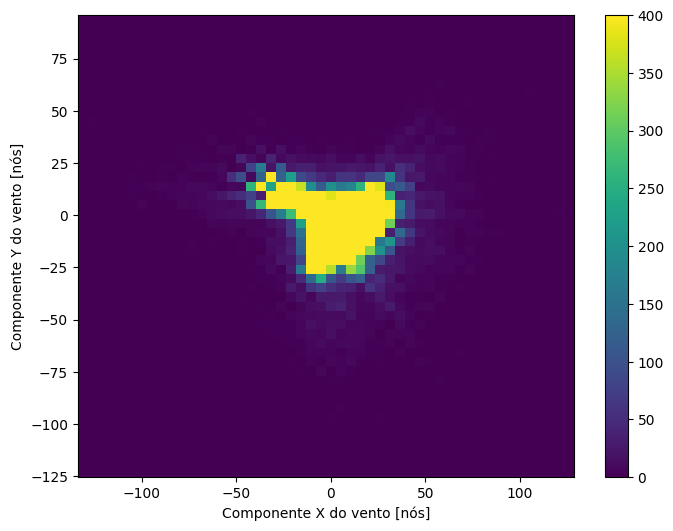

In [25]:
# Converter direção de onde o vento vem para para onde ele vai
Wind_Direction_cartesiano = (270 - df['Wind_Direction']) % 360
Wind_Direction_rad = np.radians(Wind_Direction_cartesiano)

df.loc[:,'wind_compX'] = df['Average_WSpeed_knots'] * np.cos(Wind_Direction_rad)
df.loc[:,'wind_compY'] = df['Average_WSpeed_knots'] * np.sin(Wind_Direction_rad)

# Remover NaNs para o plot
df_plot = df.dropna(subset=['wind_compX', 'wind_compY'])

plt.hist2d(df_plot['wind_compX'], df_plot['wind_compY'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Componente X do vento [nós]')
plt.ylabel('Componente Y do vento [nós]')
ax = plt.gca()
ax.axis('tight')

In [26]:
# plot_cols = ['Air_Temp', 'Dew_Point', 'Average_WSpeed_knots', 'Pressure']

# plot_features = df[plot_cols]
# _ = plot_features.plot(subplots=True)

# plot_features = df[plot_cols]['2024-01-01':'2025-02-28']
# _ = plot_features.plot(subplots=True)

# #Atualmente, a distribuição dos dados de vento se parece com esta:
# df_plot = df.dropna(subset=['Wind_Direction', 'Average_WSpeed_knots'])
# plt.hist2d(df_plot['Wind_Direction'], df_plot['Average_WSpeed_knots'], bins=(50, 50), vmax=400)
# plt.colorbar()
# plt.xlabel('Direção do vento (graus)')
# plt.ylabel('Velocidade do vento (nós)')

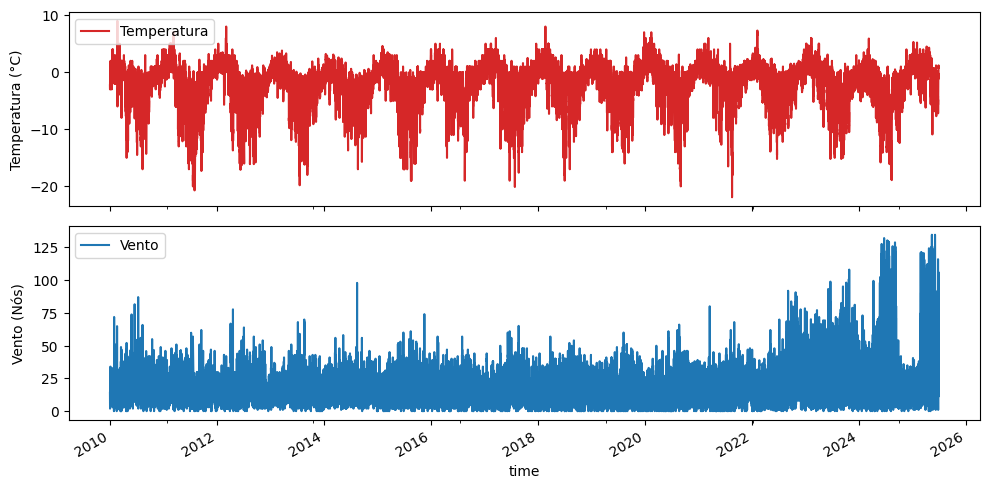

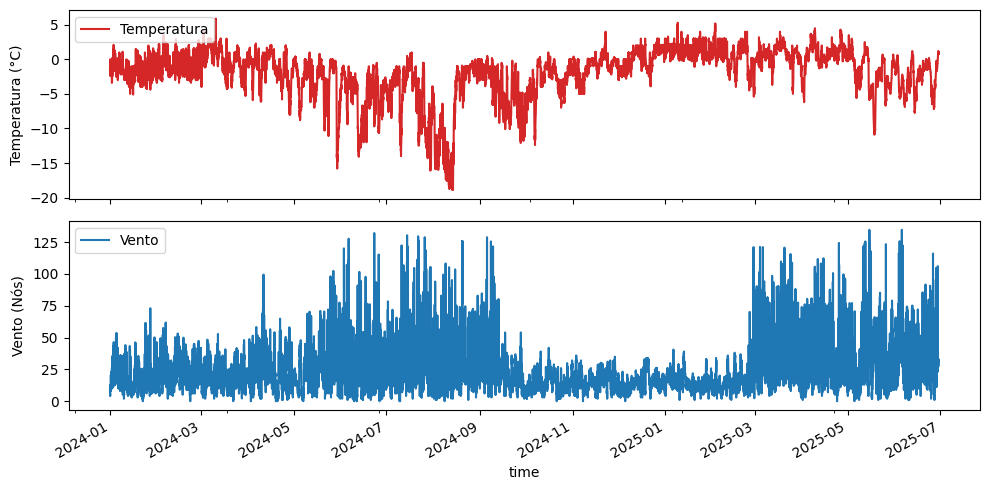

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

df['Air_Temp'].plot(ax=ax[0], color='tab:red', label='Temperatura')
ax[0].set_ylabel('Temperatura (°C)')
ax[0].legend(loc='upper left')

df['Average_WSpeed_knots'].plot(ax=ax[1], color='tab:blue', label='Vento')
ax[1].set_ylabel('Vento (Nós)')
ax[1].legend(loc='upper left')

plt.tight_layout()

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

df['Air_Temp']['2024-01-01'::].plot(ax=ax[0], color='tab:red', label='Temperatura')
ax[0].set_ylabel('Temperatura (°C)')
ax[0].legend(loc='upper left')

df['Average_WSpeed_knots']['2024-01-01'::].plot(ax=ax[1], color='tab:blue', label='Vento')
ax[1].set_ylabel('Vento (Nós)')
ax[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

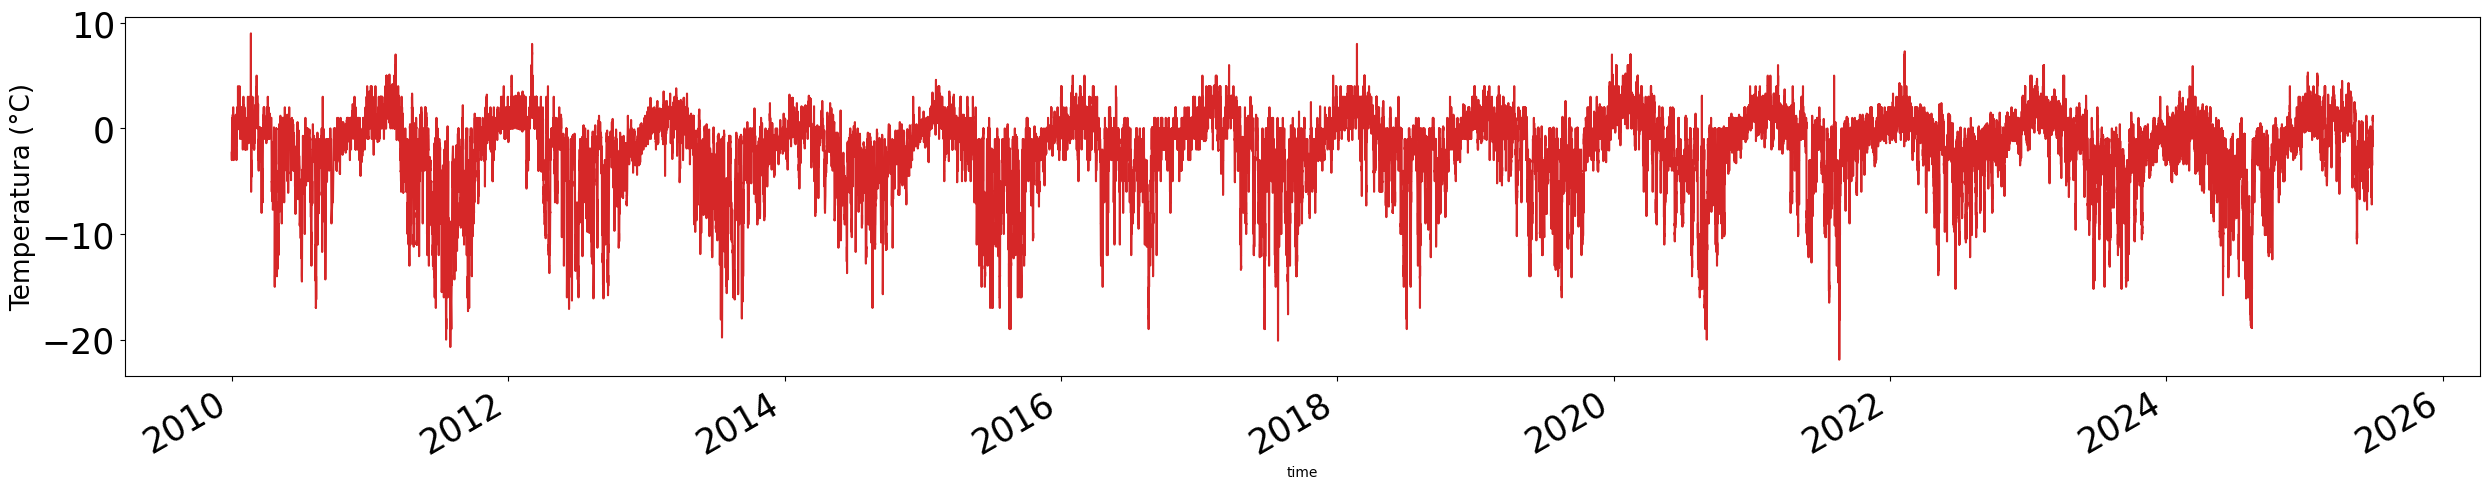

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 5))

df['Air_Temp'].plot(ax=ax, color='tab:red', label='Temperatura')

ax.set_ylabel('Temperatura (°C)', fontsize=19)  # Tamanho da fonte do eixo Y
#ax.set_xlabel('Tempo em anos', fontsize=20)              # Tamanho da fonte do eixo X (opcional)
#ax.set_title('Série Temporal da Temperatura no Aeroporto SCRM, na Antártica', fontsize=25)  # Título, se quiser

#ax.legend(loc='upper left', fontsize=20)        # Tamanho da fonte da legenda
ax.tick_params(axis='both', labelsize=25)       # Tamanho da fonte dos ticks dos eixos

plt.tight_layout()
plt.show()

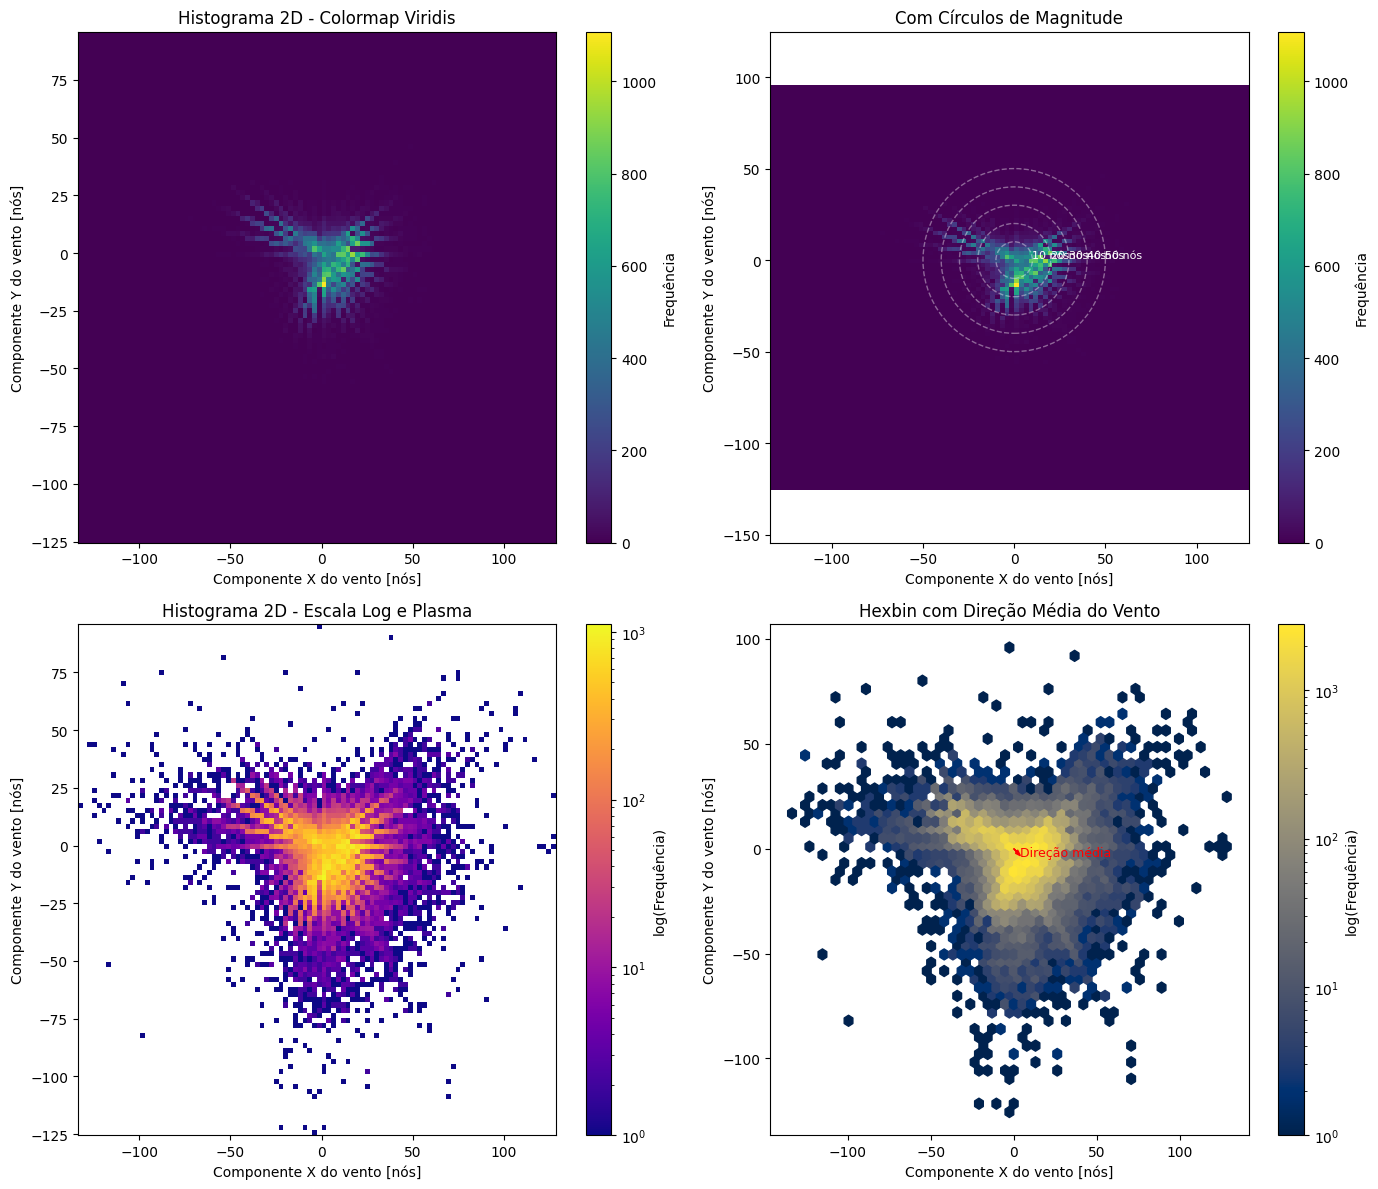

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Certifique-se de que esses campos estão calculados
Wind_Direction_cartesiano = (270 - df['Wind_Direction']) % 360
Wind_Direction_rad = np.radians(Wind_Direction_cartesiano)

df['wind_compX'] = df['Average_WSpeed_knots'] * np.cos(Wind_Direction_rad)
df['wind_compY'] = df['Average_WSpeed_knots'] * np.sin(Wind_Direction_rad)

wind_compX = df['wind_compX']
wind_compY = df['wind_compY']

# Criar figuras com subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# 1. Histograma 2D padrão com viridis
h1 = axs[0, 0].hist2d(wind_compX, wind_compY, bins=100, cmap='viridis')
axs[0, 0].set_title('Histograma 2D - Colormap Viridis')
axs[0, 0].set_xlabel("Componente X do vento [nós]")
axs[0, 0].set_ylabel("Componente Y do vento [nós]")
fig.colorbar(h1[3], ax=axs[0, 0], label='Frequência')

# 2. Histograma 2D com círculos de magnitude
h2 = axs[0, 1].hist2d(wind_compX, wind_compY, bins=100, cmap='viridis')
axs[0, 1].set_title('Com Círculos de Magnitude')
axs[0, 1].set_xlabel("Componente X do vento [nós]")
axs[0, 1].set_ylabel("Componente Y do vento [nós]")
fig.colorbar(h2[3], ax=axs[0, 1], label='Frequência')
for mag in [10, 20, 30, 40, 50]:
    circle = plt.Circle((0, 0), mag, color='white', fill=False, linestyle='--', alpha=0.4)
    axs[0, 1].add_patch(circle)
    axs[0, 1].text(mag, 0, f'{mag} nós', color='white', fontsize=8, ha='left', va='bottom')
axs[0, 1].axis('equal')

# 3. Histograma 2D com log da frequência
h3 = axs[1, 0].hist2d(wind_compX, wind_compY, bins=100, cmap='plasma', norm='log')
axs[1, 0].set_title('Histograma 2D - Escala Log e Plasma')
axs[1, 0].set_xlabel("Componente X do vento [nós]")
axs[1, 0].set_ylabel("Componente Y do vento [nós]")
fig.colorbar(h3[3], ax=axs[1, 0], label='log(Frequência)')

# 4. Hexbin com direção média
hb = axs[1, 1].hexbin(wind_compX, wind_compY, gridsize=50, cmap='cividis', bins='log')
axs[1, 1].set_title('Hexbin com Direção Média do Vento')
axs[1, 1].set_xlabel("Componente X do vento [nós]")
axs[1, 1].set_ylabel("Componente Y do vento [nós]")
fig.colorbar(hb, ax=axs[1, 1], label='log(Frequência)')

# Direção média do vetor vento
U_mean = wind_compX.mean()
V_mean = wind_compY.mean()
axs[1, 1].arrow(0, 0, U_mean, V_mean, color='red', head_width=2, length_includes_head=True)
axs[1, 1].text(U_mean, V_mean, 'Direção média', color='red', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
Average_WSpeed_knots = df.pop('Average_WSpeed_knots')
Weather_Cond_Code = df.pop('Weather_Cond_Code')
Total_Precip = df.pop('Total_Precip')

In [31]:
# Aqui está sendo feito o drop de Wind_Direction

df.drop(['Wind_Direction'], axis=1, inplace=True)

In [32]:
df.loc[:,'year'] = df.index.year
df.loc[:,'month'] = df.index.month
df.loc[:,'day'] = df.index.day
df.loc[:,'hour'] = df.index.hour

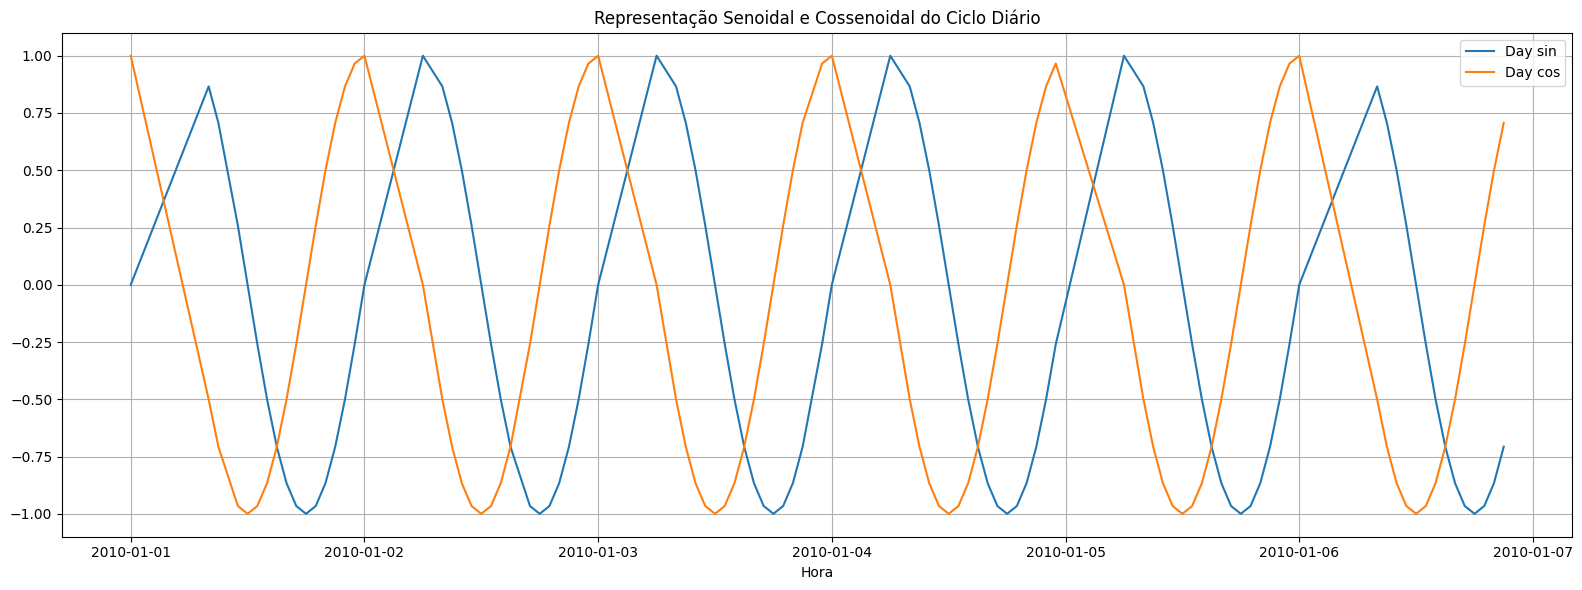

In [33]:
# Garantir que o índice está em datetime
df.index = pd.to_datetime(df.index)

# Transformar o índice para timestamp em segundos
timestamp_s = df.index.view('int64') // 1_000_000_000  # segundos desde época UNIX

# Constantes
day = 24*60*60
year = 365.2425*day

# Cálculo dos componentes sazonais
df.loc[:,'Day sin'] = np.sin(2 * np.pi * timestamp_s / day)
df.loc[:,'Day cos'] = np.cos(2 * np.pi * timestamp_s / day)
df.loc[:,'Year sin'] = np.sin(2 * np.pi * timestamp_s / year)
df.loc[:,'Year cos'] = np.cos(2 * np.pi * timestamp_s / year)

# Visualizar o ciclo diário nos primeiros 24 pontos (ou 25 horas)
plt.figure(figsize=(16, 6))
plt.plot(df['Day sin'][:100], label='Day sin')
plt.plot(df['Day cos'][:100], label='Day cos')
plt.xlabel('Hora')
plt.title('Representação Senoidal e Cossenoidal do Ciclo Diário')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
df.head()
df.describe().transpose()
df.isna().any().any()

np.False_

## Dividir os dados (Split the data)

Você usará uma divisão **(70%, 20%, 10%)** para os conjuntos de **treinamento, validação e teste**. Observe que os dados não são embaralhados aleatoriamente antes da divisão. Isso ocorre por dois motivos:

Isso garante que ainda seja possível dividir os dados em janelas de amostras consecutivas.
Isso garante que os resultados da validação/teste sejam mais realistas, sendo avaliados com base nos dados coletados após o treinamento do modelo.

In [35]:
column_indices = {name: i for i, name in enumerate(df.columns)}
n = len(df)
print(n)

train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

106833


## Normalização (escalonamento) dos dados
É importante escalonar os atributos antes de treinar uma rede neural. A normalização é a maneira mais comum de fazer esse escalonamento. Fórmula => [atributo(feature-média]/[desvio padrão], isso para cada atributo do conjunto de dados.

### Importante:
A média e o desvio padrão devem ser calculados apenas usando os dados de treinamento para que **os modelos não tenham acesso aos valores nos conjuntos de validação e teste.**

In [36]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

/tmp/ipython-input-1335022677.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


,Column,Normalized
0,Air_Temp,-0.088042
1,Air_Temp,-0.270063
2,Air_Temp,-0.270063
3,Air_Temp,-0.010033
4,Air_Temp,0.197990


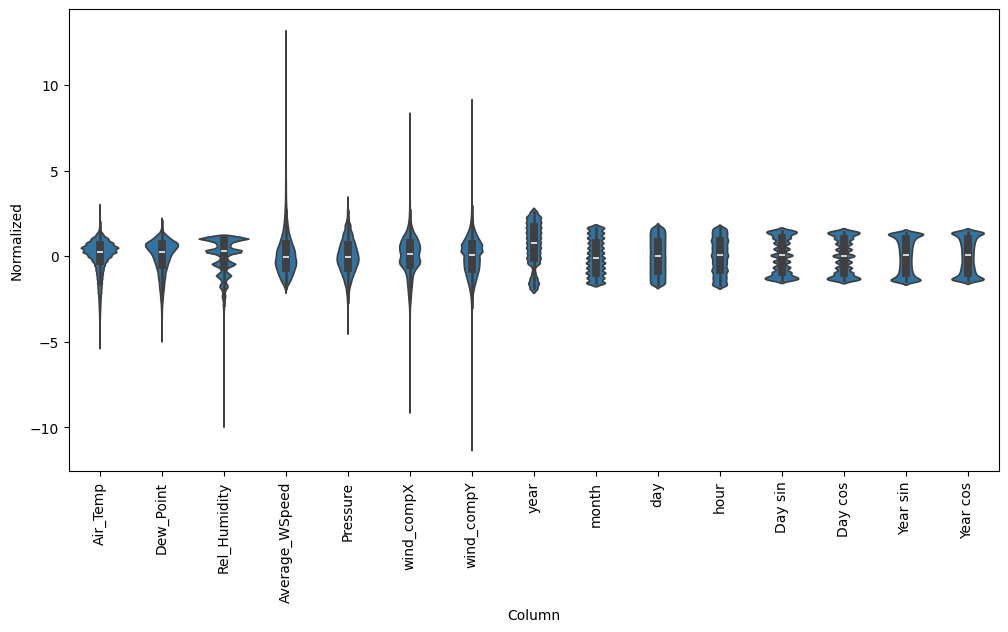

In [37]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')

plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

df_std.head()

## Classe Auxiliar - WindowGenerator()

In [38]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df, label_columns=None):
        # Armazena os dados
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # Colunas de interesse
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        # Parâmetros da janela
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'
        ])

    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]

        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1)

            inputs = tf.stack(
                [inputs[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1)

        return inputs, labels

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=32,
        )
        return ds.map(self.split_window)

    @property
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def val(self):
        return self.make_dataset(self.val_df)

    @property
    def test(self):
        return self.make_dataset(self.test_df)

    @property
    def example(self):
        """Retorna um único batch do conjunto de teste, útil para visualização."""
        return next(iter(self.test))

    def plot(self, models=None, plot_col='Air_Temp', max_subplots=3):
        inputs, labels = self.example
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))

        all_preds = {}
        if models:
            for name in models:
                preds = models[name](inputs)
                all_preds[name] = preds.numpy()

        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normalizado]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                     label='Entrada', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', label='Observado', c='#2ca02c', s=64)

            if models is not None:
                for name, preds in all_preds.items():
                    plt.scatter(self.label_indices,
                                preds[n, :, label_col_index],
                                marker='X', edgecolors='k',
                                label=name,
                                s=64)

            if n == 0:
                plt.legend()
        plt.xlabel('Tempo [horas]')
        return all_preds


In [39]:
w1 = WindowGenerator(
    input_width=24,
    label_width=1,
    shift=24,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)
w1

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['Air_Temp']

In [40]:
w2 = WindowGenerator(
    input_width=6,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)
w2

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['Air_Temp']

In [41]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [42]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 15)
Inputs shape: (3, 6, 15)
Labels shape: (3, 1, 1)


In [43]:
example_inputs, example_labels = w2.example

Este def plolt é o original!!!!!!!!

NOVO Def PLOT

In [45]:
#def plot(self, models=None, plot_col='Air_Temp', max_subplots=3):
#    inputs, labels = self.example
#    plt.figure(figsize=(12, 8))
#    plot_col_index = self.column_indices[plot_col]
#    max_n = min(max_subplots, len(inputs))

#    for n in range(max_n):
#        plt.subplot(max_n, 1, n+1)
#        plt.ylabel(f'{plot_col} [normalizado]')
#        plt.plot(self.input_indices, inputs[n, :, plot_col_index],
#                 label='Entrada', marker='.', zorder=-10)

#        if self.label_columns:
#            label_col_index = self.label_columns_indices.get(plot_col, None)
#        else:
#            label_col_index = plot_col_index

#        if label_col_index is None:
#            continue

#        plt.scatter(self.label_indices, labels[n, :, label_col_index],
 #                   edgecolors='k', label='Observado', c='#2ca02c', s=64)

 #       if models is not None:
 #           for name, model in models.items():
 #               preds = model(inputs)
 #               plt.scatter(self.label_indices,
 #                           preds[n, :, label_col_index],
 #                           marker='X', edgecolors='k',
 #                           label=name,
  #                          s=64)

  #      if n == 0:
  #          plt.legend()
  #  plt.xlabel('Tempo [horas]')

# Substitui o método na classe
#WindowGenerator.plot = plot


In [46]:
def plot(self, models=None, plot_col='Air_Temp', max_subplots=3):
    inputs, labels = self.example
    plt.figure(figsize=(12, 8))
    plot_col_index = self.column_indices[plot_col]
    max_n = min(max_subplots, len(inputs))

    all_preds = {}  # <- dicionário para armazenar as previsões

    for name in models or []:
        preds = models[name](inputs)
        all_preds[name] = preds.numpy()  # salva os valores como numpy array

    for n in range(max_n):
        plt.subplot(max_n, 1, n+1)
        plt.ylabel(f'{plot_col} [normalizado]')
        plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                 label='Entrada', marker='.', zorder=-10)

        if self.label_columns:
            label_col_index = self.label_columns_indices.get(plot_col, None)
        else:
            label_col_index = plot_col_index

        if label_col_index is None:
            continue

        plt.scatter(self.label_indices, labels[n, :, label_col_index],
                    edgecolors='k', label='Observado', c='#2ca02c', s=64)

        if models is not None:
            for name, preds in all_preds.items():
                plt.scatter(self.label_indices,
                            preds[n, :, label_col_index],
                            marker='X', edgecolors='k',
                            label=name,
                            s=64)

        if n == 0:
            plt.legend()
    plt.xlabel('Tempo [horas]')

    return all_preds  # <- adiciona esse retorno


{}

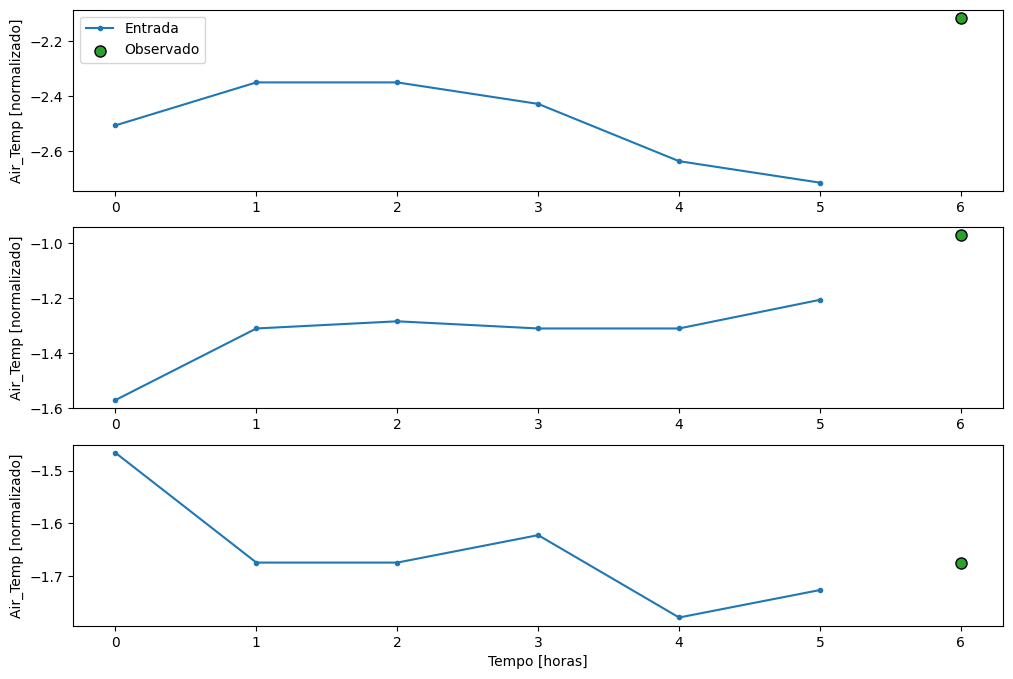

In [47]:
#w2.plot()
plot(w2)


In [48]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack([labels[:, :, self.column_indices[name]] for name in self.label_columns], axis=-1)
  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [49]:
#Primeira janela com shift de 24 horas, com 24 horas de dados anteriores
w1 = WindowGenerator(
    input_width=24,
    label_width=1,
    shift=24,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)
w1


Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['Air_Temp']

In [50]:
w2 = WindowGenerator(
    input_width=6,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)
w2


Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['Air_Temp']

In [51]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 15)
Inputs shape: (3, 6, 15)
Labels shape: (3, 1, 1)


In [52]:
example_inputs, example_labels = w2.example

In [53]:
#w2.plot()

Create tf.data.Datasets

Finally, this make_dataset method will take a time series DataFrame and convert it to a tf.data.Dataset of (input_window, label_window) pairs using the tf.keras.utils.timeseries_dataset_from_array function:

In [54]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [55]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [56]:
# Each element is an (inputs, label) pair.
w2.train.element_spec

(TensorSpec(shape=(None, 6, 15), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [57]:
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 15)
Labels shape (batch, time, features): (32, 1, 1)


# METAR com Temperatura - Modelos de Aprendizado de Máquina - MSE

Single step models
The simplest model you can build on this sort of data is one that predicts a single feature's value—1 time step (one hour) into the future based only on the current conditions.

So, start by building models to predict the T (degC) value one hour into the future.
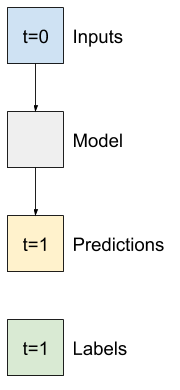

Predict the next time step

Configure a WindowGenerator object to produce these single-step (input, label) pairs:

## ARIMA - METAR com Temperatura

In [58]:
#from statsmodels.tsa.arima.model import ARIMA
#import matplotlib.pyplot as plt

#series = df['Air_Temp'].values[-200:]

#model = ARIMA(series, order=(2,1,1))
#model_fit = model.fit()
#forecast = model_fit.forecast(steps=6)

# Plot
#plt.figure(figsize=(12, 5))
#plt.plot(series, label='Observado')
#plt.plot(np.arange(len(series), len(series)+6), forecast, label='Previsão')
#plt.legend()
#plt.grid(True)
#plt.title("Previsão ARIMA com statsmodels")
#plt.show()

In [59]:
single_step_window = WindowGenerator(
    input_width=1,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)
single_step_window


Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['Air_Temp']

In [60]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 1, 15)
Labels shape (batch, time, features): (32, 1, 1)


## Baseline - METAR com Temperatura - MSE

In [61]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

In [62]:
baseline = Baseline(label_index=column_indices['Air_Temp'])

baseline_fit_start = time.time()
baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])
baseline_fit_end = time.time()
baseline_fit_elapsed = baseline_fit_end - baseline_fit_start
tempos_treinamento['baseline'] = baseline_fit_elapsed

baseline_val_start = time.time()
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
baseline_val_end = time.time()
baseline_val_elapsed = baseline_val_end - baseline_val_start
tempos_validacao['baseline'] = baseline_val_elapsed

baseline_test_start = time.time()
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)
baseline_test_end = time.time()
baseline_test_elapsed = baseline_test_end - baseline_test_start
tempos_teste['baseline'] = baseline_test_elapsed

668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0368 - mean_absolute_error: 0.1197


In [63]:
print(baseline.summary())

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [64]:
tempos_teste

{'baseline': 1.325042724609375}

In [65]:
tempos_validacao

{'baseline': 3.739760637283325}

In [66]:
tempos_treinamento

{'baseline': 0.02308058738708496}

In [67]:
modelo = 'baseline'
print(f"MODELO: {modelo}")
print(f"Tempo de treinamento: {tempos_treinamento[modelo]} s")
print(f"Tempo de validação: {tempos_validacao[modelo]} s")
print(f"Tempo de teste/inferência: {tempos_teste[modelo]} s")

MODELO: baseline
Tempo de treinamento: 0.02308058738708496 s
Tempo de validação: 3.739760637283325 s
Tempo de teste/inferência: 1.325042724609375 s


In [68]:
for example_inputs, example_labels in w2.test.take(1):
    print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
    predictions = baseline(example_inputs)
    print(f'Predictions shape: {predictions.shape}')
    print(predictions)


Inputs shape (batch, time, features): (32, 6, 15)
Predictions shape: (32, 6, 1)
tf.Tensor(
[[[ 0.24999624]
  [-0.01003318]
  [-0.21805672]
  [-0.24405967]
  [-0.27006263]
  [-0.29606557]]

 [[-3.1303864 ]
  [-3.1303864 ]
  [-2.8703568 ]
  [-2.8703568 ]
  [-2.8703568 ]
  [-3.0523775 ]]

 [[ 0.4580198 ]
  [ 0.4060139 ]
  [ 0.4580198 ]
  [ 0.5100257 ]
  [ 0.48402274]
  [ 0.5100257 ]]

 [[-0.01003318]
  [-0.03603613]
  [ 0.09397858]
  [-0.03603613]
  [-0.01003318]
  [ 0.19799036]]

 [[ 0.5100257 ]
  [ 0.6920463 ]
  [ 0.7700551 ]
  [ 0.7700551 ]
  [ 0.5880345 ]
  [ 0.5100257 ]]

 [[-0.03603613]
  [-0.01003318]
  [ 0.17198741]
  [ 0.06797564]
  [ 0.19799036]
  [ 0.17198741]]

 [[-0.19205378]
  [-0.06203907]
  [ 0.11998153]
  [ 0.24999624]
  [ 0.32800508]
  [ 0.38001096]]

 [[ 0.4060139 ]
  [ 0.19799036]
  [ 0.4580198 ]
  [ 0.56203157]
  [ 0.4580198 ]
  [ 0.11998153]]

 [[-0.24405967]
  [-0.27006263]
  [-0.27006263]
  [-0.34807146]
  [-0.27006263]
  [-0.4000773 ]]

 [[-0.4520832 ]
  [-0.50408

loss: 0.3....Valor da função de perda, que é o Mean Squared Error (MSE) neste caso. Indica o erro quadrático médio entre as predições e os valores reais. Quanto menor, melhor. O MSE de 0.02....mostra a média dos erros quadrados, que penaliza erros maiores.

mean_absolute_error: 0.3 Métrica de erro médio absoluto (MAE). Representa a média das diferenças absolutas entre as predições e valores reais. O baseline está errando em média cerca de 0.3 unidades da variável prevista (exemplo: graus de temperatura, se for temperatura).


In [69]:
wide_window = WindowGenerator(
    input_width=24,
    label_width=24,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)
wide_window


Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['Air_Temp']

[-3.99999979e-01 -3.99999979e-01 -9.99999711e-02 -2.99999976e-01
  3.15110764e-08  3.15110764e-08 -9.99999711e-02  3.15110764e-08
  1.00000006e+00  6.00000047e-01  1.00000006e+00  1.00000006e+00
  1.30000007e+00  1.99999985e+00  1.00000006e+00  1.40000007e+00
  1.10000006e+00  1.00000006e+00  1.10000006e+00  9.00000055e-01
  1.00000006e+00  9.00000055e-01  1.10000006e+00  1.00000006e+00]


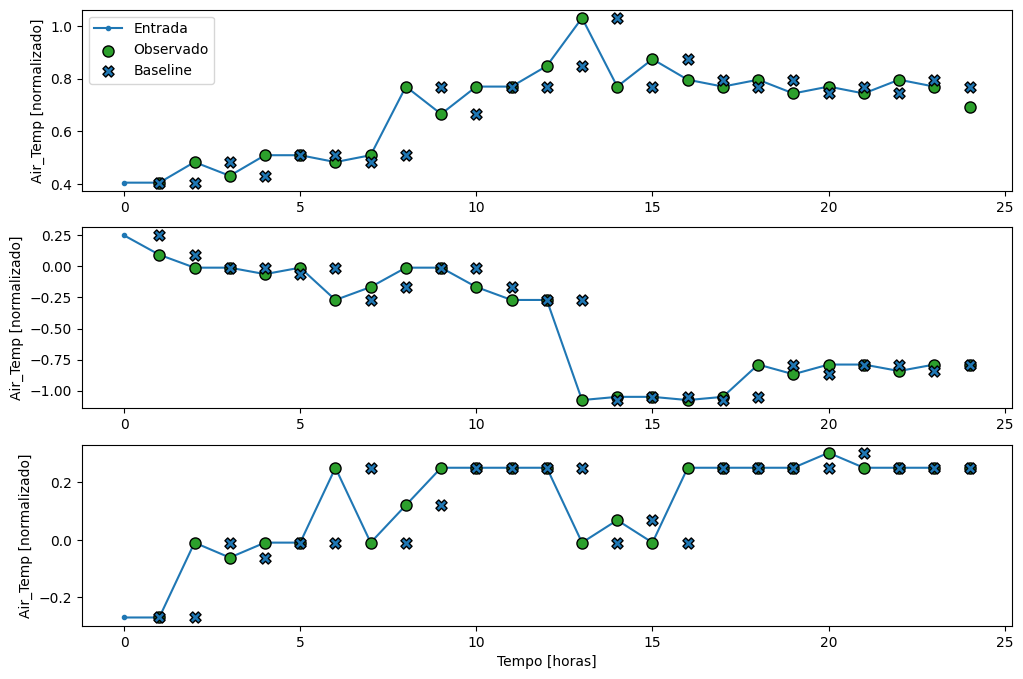

In [70]:
#wide_window.plot(baseline, plot_col='Air_Temp', max_subplots=3)
preds= wide_window.plot(models={'Baseline': baseline}, plot_col='Air_Temp', max_subplots=3)

# Extrair previsões do modelo baseline para o primeiro exemplo do batch
baseline_preds = preds['Baseline'][0, :, 0]

# Usar a média e o desvio apenas da coluna Air_Temp
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# Desnormalizar
baseline_preds_desnorm = baseline_preds * std_temp + mean_temp
print(baseline_preds_desnorm)

# Salvar como CSV (opcional)
# df_preds = pd.DataFrame({'Forecast_Linear': linear_preds_desnorm.numpy()})
# df_preds.to_csv('previsao_linear.csv', index=False)


## Função Auxiliar - compile_and_fit - Suporte a MAE, MAPE, RMSE e MSE.

In [71]:
MAX_EPOCHS = 20

# O método "early_stopping" monitora o desempenho do modelo durante o treino.
# Ela monitora a métrica 'val_loss' (perda no conjunto de validação).
# Se a validação não melhorar após patience épocas (aqui, 2), o treino para antes do limite máximo.
# mode='min' indica que queremos minimizar a perda.
# patience: quantas épocas o treino espera para tentar melhorar a validação antes de parar (early stopping).

def root_mean_squared_error(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

def compile_and_fit(model, window, model_name, patience=2, time_based=True, loss_type='MSE'):
    """Função auxiliar para treinar modelos com monitoramento automático."""
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        mode='min'
    )

    resource_monitor = ResourceMonitorCallback(model_name=model_name, time_based=time_based)

    # Seleciona a função de perda
    if loss_type == 'MAPE':
        loss_function = tf.keras.losses.MeanAbsolutePercentageError()
        extra_metrics = [tf.keras.metrics.MeanAbsoluteError()]
    elif loss_type == 'MAE':
        loss_function = tf.keras.losses.MeanAbsoluteError()
        extra_metrics = [tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanAbsolutePercentageError(), tf.keras.metrics.MeanSquaredError()]
    elif loss_type == 'RMSE':
        loss_function = tf.keras.losses.MeanSquaredError()  # Loss continua sendo MSE
        extra_metrics = [tf.keras.metrics.MeanAbsoluteError(), root_mean_squared_error]
    elif loss_type == 'MSE':
        loss_function = tf.keras.losses.MeanSquaredError()
        extra_metrics = [tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanAbsolutePercentageError(), tf.keras.metrics.MeanSquaredError()]
    else:
        raise ValueError(f"Loss type '{loss_type}' não suportado.")

    model.compile(
        loss=loss_function,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=extra_metrics
    )

    history = model.fit(
        window.train,
        epochs=MAX_EPOCHS,
        validation_data=window.val,
        callbacks=[early_stopping, resource_monitor],
        verbose=1
    )

    #resource_monitor.plot_metrics()
    return history

## Linear - METAR com Temperatura - MSE

The simplest trainable model you can apply to this task is to insert linear transformation between the input and output. In this case the output from a time step only depends on that step:
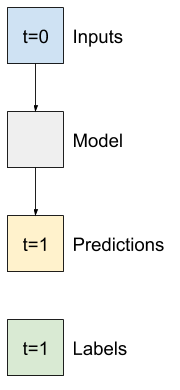



In [72]:
modelo = 'Linear'

if modo_execucao == 'Treinamento':
  linear = tf.keras.Sequential([
      tf.keras.layers.Dense(units=1)
  ])
  print('Input shape:', single_step_window.example[0].shape)
  print('Output shape:', linear(single_step_window.example[0]).shape)

  linear_fit_start = time.time()
  history = compile_and_fit(linear, single_step_window, model_name='Linear')
  linear_fit_end = time.time()
  linear_fit_elapsed = linear_fit_end - linear_fit_start
  tempos_treinamento[modelo] = linear_fit_elapsed
else:
  linear = tf.keras.models.load_model(f"{lista_modelos['Linear']}")

linear_val_start = time.time()
val_performance['Linear'] = linear.evaluate(single_step_window.val, return_dict=True)
linear_val_end = time.time()
linear_val_elapsed = linear_val_end - linear_val_start
tempos_validacao[modelo] = linear_val_elapsed

linear_test_start = time.time()
performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0, return_dict=True)
linear_test_end = time.time()
linear_test_elapsed = linear_test_end - linear_test_start
tempos_teste[modelo] = linear_test_elapsed

Input shape: (32, 1, 15)
Output shape: (32, 1, 1)
Epoch 1/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 0.4617 - mean_absolute_error: 0.4440 - mean_absolute_percentage_error: 428.6471 - mean_squared_error: 0.4617 - root_mean_squared_error: 0.6399 - val_loss: 0.0344 - val_mean_absolute_error: 0.1203 - val_mean_absolute_percentage_error: 103.7509 - val_mean_squared_error: 0.0344 - val_root_mean_squared_error: 0.1855
Epoch 2/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.0335 - mean_absolute_error: 0.1126 - mean_absolute_percentage_error: 95.9358 - mean_squared_error: 0.0335 - root_mean_squared_error: 0.1830 - val_loss: 0.0346 - val_mean_absolute_error: 0.1222 - val_mean_absolute_percentage_error: 106.8137 - val_mean_squared_error: 0.0346 - val_root_mean_squared_error: 0.1859
Epoch 3/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0335 - mean_absolute_error: 0.1132 - mean_absolute_percentage_error: 96.8485 - mean_squared_error: 0.0335 - root_mean_squared_error

In [73]:
datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
if modo_execucao == 'Treinamento':
  linear.save(f"{modelo}_{datahora}.keras")

print(f"MODELO: {modelo}")
print(f"Tempo de treinamento: {tempos_treinamento[modelo]} s")
print(f"Tempo de validação: {tempos_validacao[modelo]} s")
print(f"Tempo de teste/inferência: {tempos_teste[modelo]} s")

MODELO: Linear
Tempo de treinamento: 65.94876909255981 s
Tempo de validação: 2.8306796550750732 s
Tempo de teste/inferência: 2.0066070556640625 s


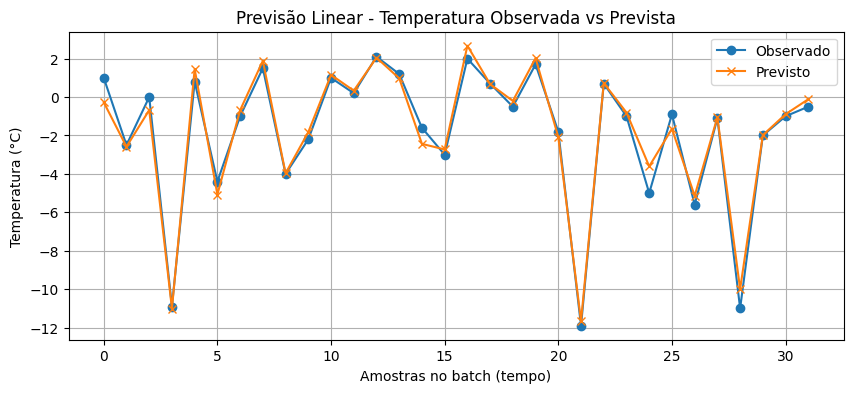

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Obtemos um batch do dataset de teste
for inputs, labels in single_step_window.test.take(1):
    predictions = linear(inputs)  # faz a predição com o modelo treinado

# Converte para numpy e remove dimensões extras
true = labels.numpy().squeeze()        # shape (batch_size,)
pred = predictions.numpy().squeeze()   # shape (batch_size,)

# Reverte a normalização z-score (supondo train_mean e train_std definidos para 'Air_Temp')
true_orig = true * train_std['Air_Temp'] + train_mean['Air_Temp']
pred_orig = pred * train_std['Air_Temp'] + train_mean['Air_Temp']

# Plotagem
plt.figure(figsize=(10, 4))
plt.plot(true_orig, label='Observado', marker='o')
plt.plot(pred_orig, label='Previsto', marker='x')
plt.title('Previsão Linear - Temperatura Observada vs Prevista')
plt.xlabel('Amostras no batch (tempo)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()


[-0.57693227 -0.50432977 -0.1983843  -0.39167404 -0.05305402 -0.0526609
 -0.13453833 -0.03005817  0.95600443  0.54388244  0.90982064  0.88766146
  1.08660222  1.60131191  0.70052061  1.13371895  0.80857229  0.70609669
  0.81708035  0.61763782  0.71836262  0.6913909   0.82608995  0.73421452]


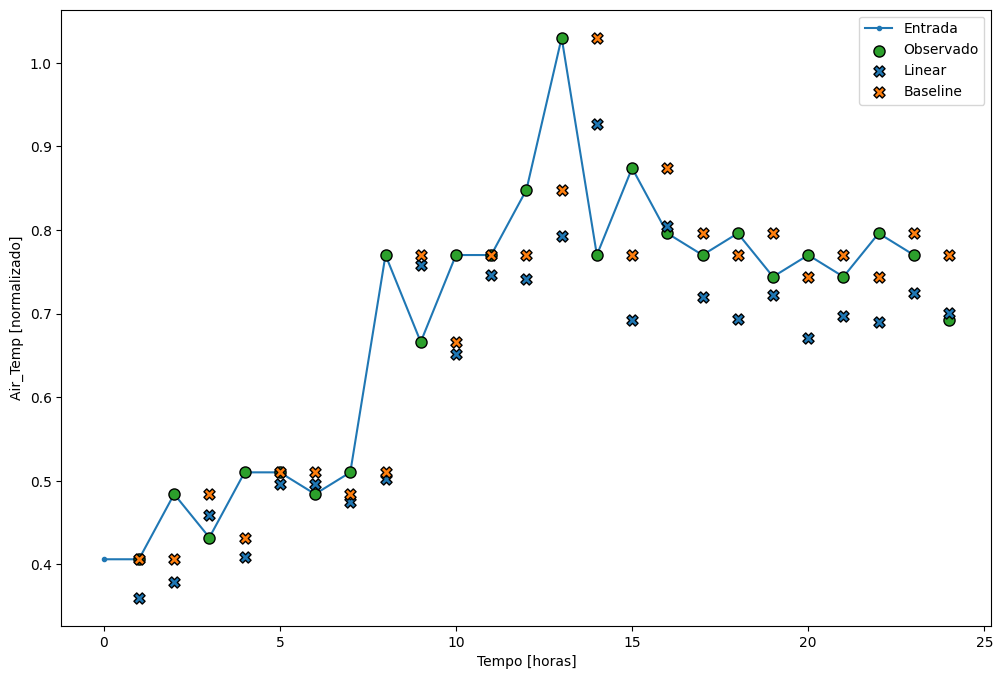

In [75]:
# Executa o plot e retorna previsões
preds = wide_window.plot(
    models={'Linear': linear, 'Baseline': baseline},
    plot_col='Air_Temp',
    max_subplots=1
)

# Extrair previsões do modelo Linear para o primeiro exemplo do batch
linear_preds = preds['Linear'][0, :, 0]

# Usar a média e o desvio apenas da coluna Air_Temp
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# Desnormalizar
linear_preds_desnorm = linear_preds * std_temp + mean_temp
print(linear_preds_desnorm)

# Salvar como CSV (opcional)
# df_preds = pd.DataFrame({'Forecast_Linear': linear_preds_desnorm.numpy()})
# df_preds.to_csv('previsao_linear.csv', index=False)


In [76]:
#model.predict(dataset)

In [77]:
#wide_window.plot(linear)

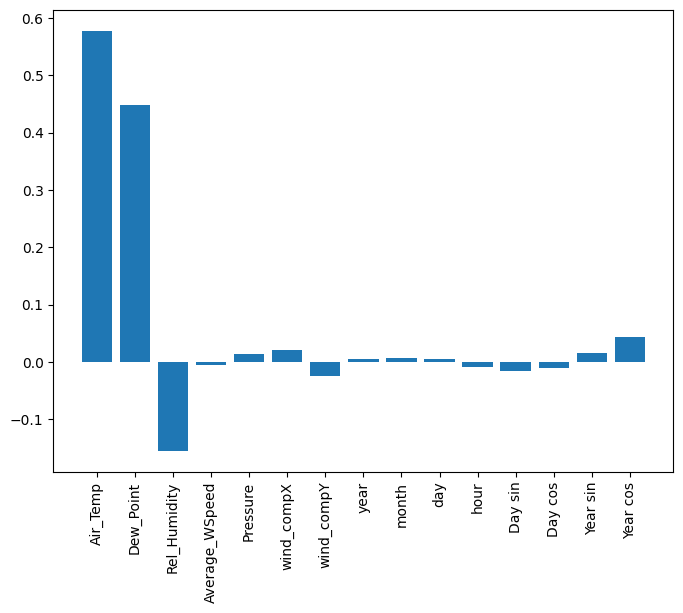

In [78]:
plt.bar(x = range(len(train_df.columns)), height=linear.layers[0].kernel[:,0].numpy())
axis = plt.gca()

axis.set_xticks(range(len(train_df.columns)))
_ = axis.set_xticklabels(train_df.columns, rotation=90)

## Multi-Layer Perceptron (MLP) - 'DENSE' - METAR com Temperatura - MSE

Before applying models that actually operate on multiple time-steps, it's worth checking the performance of deeper, more powerful, single input step models.

Here's a model similar to the linear model, except it stacks several a few Dense layers between the input and the output.

**perceptron multicamadas (MLP)** simples para problemas de regressão, como o nosso para prever estimar temperatura.

Esse modelo tem 3 camadas densas (fully connected):
* Primeira camada: 64 neurônios, função de ativação ReLU (relu), que introduz não linearidade.

* Segunda camada: mais 64 neurônios com ativação ReLU.

* Terceira camada: camada de saída com 1 neurônio (sem ativação explícita, padrão é linear), para regressão (ex: prever temperatura).



In [79]:
#if modo_execucao == 'Treinamento':
 # dense = tf.keras.Sequential([
 #     tf.keras.layers.Dense(units=64, activation='relu'),
 #     tf.keras.layers.Dense(units=64, activation='relu'),
  #    tf.keras.layers.Dense(units=1)
  #])

  #history = compile_and_fit(dense, single_step_window, model_name='mlp')
#else:
  #dense = tf.keras.models.load_model(f"{lista_modelos['mlp']}")

#val_performance['Dense'] = dense.evaluate(single_step_window.val, return_dict=True)
#performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

In [80]:
#datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
#if modo_execucao == 'Treinamento':
 # dense.save(f"mlp_{datahora}.keras")

O erro deu alto e o gráfico abaixo mostra isso:

* Vamos aplicar o Dropout ou aqui vou aplicar => L2 regularization para evitar overfitting.

## Multi-Layer Perceptron (MLP) - 'DENSE_2' - METAR com Temperatura - MSE

In [81]:
if modo_execucao == 'Treinamento':
  dense = tf.keras.Sequential([
      tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
      tf.keras.layers.Dropout(0.2),
      tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
      tf.keras.layers.Dense(1)
  ])

  history = compile_and_fit(dense, single_step_window, model_name='mlp2')
else:
  dense = tf.keras.models.load_model(f"{lista_modelos['mlp2']}")

val_performance['Dense'] = dense.evaluate(single_step_window.val, return_dict=True)
performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.1632 - mean_absolute_error: 0.2123 - mean_absolute_percentage_error: 166.1273 - mean_squared_error: 0.0996 - root_mean_squared_error: 0.3034 - val_loss: 0.0568 - val_mean_absolute_error: 0.1315 - val_mean_absolute_percentage_error: 122.3588 - val_mean_squared_error: 0.0376 - val_root_mean_squared_error: 0.1940
Epoch 2/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0543 - mean_absolute_error: 0.1330 - mean_absolute_percentage_error: 107.9647 - mean_squared_error: 0.0394 - root_mean_squared_error: 0.1983 - val_loss: 0.0456 - val_mean_absolute_error: 0.1305 - val_mean_absolute_percentage_error: 108.0547 - val_mean_squared_error: 0.0377 - val_root_mean_squared_error: 0.1943
Epoch 3/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0435 - mean_absolute_error: 0.1262 - mean_absolute_percentage_error: 100.0003 - mean_squared_error: 0.0364 - root_mean_squared_error: 0.1907 - val_loss: 0.0475 - val_mean_absolute_e

In [82]:
datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
if modo_execucao == 'Treinamento':
  dense.save(f"mlp2_{datahora}.keras")

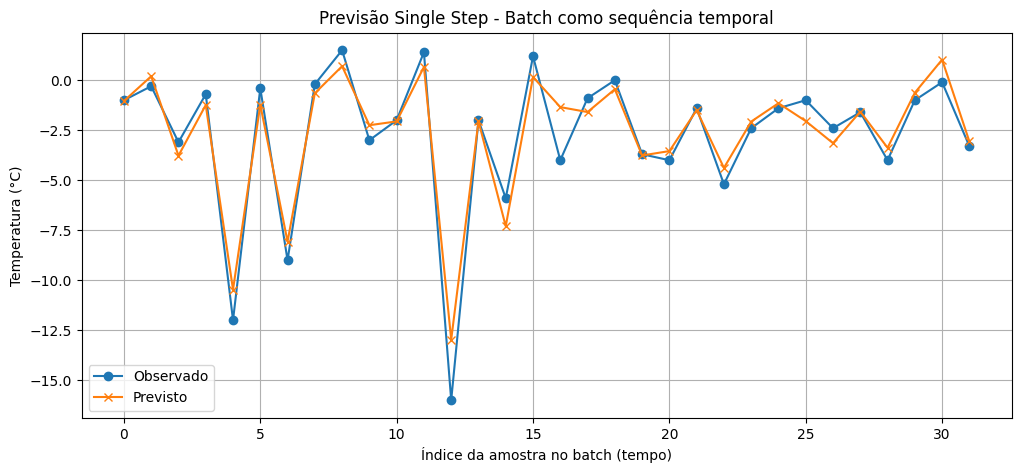

In [83]:
import numpy as np
import matplotlib.pyplot as plt

for inputs, labels in single_step_window.test.take(1):
    predictions = dense(inputs)

# labels e predictions tem shape (batch_size, 1, 1)
# Vamos pegar a dimensão batch para plotar no eixo x
true = labels.numpy().squeeze()       # shape (batch_size,)
pred = predictions.numpy().squeeze()  # shape (batch_size,)

# Reverter normalização
true_orig = true * train_std['Air_Temp'] + train_mean['Air_Temp']
pred_orig = pred * train_std['Air_Temp'] + train_mean['Air_Temp']

plt.figure(figsize=(12, 5))
plt.plot(true_orig, label='Observado', marker='o')
plt.plot(pred_orig, label='Previsto', marker='x')
plt.title('Previsão Single Step - Batch como sequência temporal')
plt.xlabel('Índice da amostra no batch (tempo)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()


[-0.69406495 -0.75627232 -0.53586393 -0.62188227 -0.40640354 -0.39707028
 -0.45801922 -0.41854432  0.35327254  0.02055328  0.2850114   0.25292228
  0.37780189  0.69295145  0.06602281  0.34782598  0.09346008  0.03078533
  0.14494808  0.00682651  0.08562158  0.10298383  0.15566172  0.07536868]


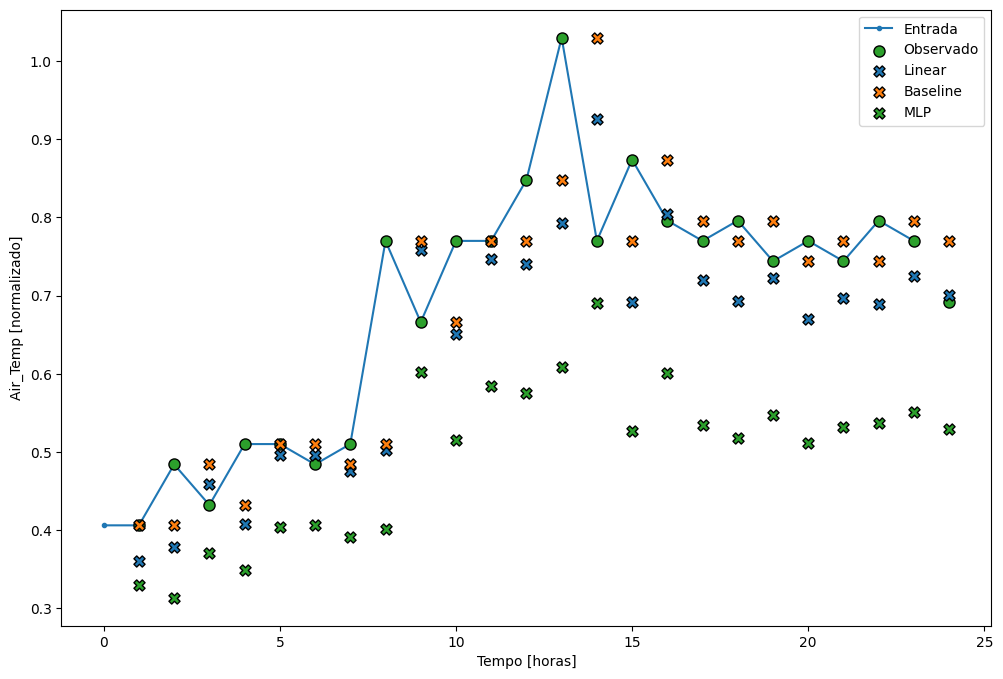

In [84]:
preds = wide_window.plot(
    models={'Linear': linear, 'Baseline': baseline, 'MLP': dense},
    plot_col='Air_Temp',
    max_subplots=1
)

# Extrair previsões do modelo Linear para o primeiro exemplo do batch
MLP_preds = preds['MLP'][0, :, 0]

# Usar a média e o desvio apenas da coluna Air_Temp
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# Desnormalizar
MLP_preds_desnorm = MLP_preds * std_temp + mean_temp
print(MLP_preds_desnorm)

# Salvar como CSV (opcional)
# df_preds = pd.DataFrame({'Forecast_Linear': linear_preds_desnorm.numpy()})
# df_preds.to_csv('previsao_linear.csv', index=False)



In [85]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', linear(wide_window.example[0]).shape)

#wide_window.plot(dense)

Input shape: (32, 24, 15)
Output shape: (32, 24, 1)


**Multi-step dense**

A single-time-step model has no context for the current values of its inputs. It can't see how the input features are changing over time. To address this issue the model needs access to multiple time steps when making predictions. The baseline, linear and dense (MLP) models handled each time step independently.

Here the model will take multiple time steps as input to produce a single output.

Create a WindowGenerator that will produce batches of three-hour inputs and one-hour labels:

Note that the Window's shift parameter is relative to the end of the two windows.

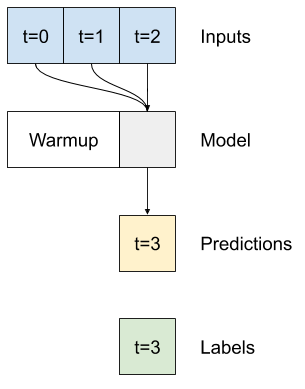

In [86]:
CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)


Vamos treinar uma modelo de Multiple-Input-STEP adicionando tf.keras.layers.Flatten na primeira camada do modelo.

In [87]:
if modo_execucao == 'Treinamento':
  multi_step_dense = tf.keras.Sequential([
      # Shape: (time, features) => (time*features)
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(units=32, activation='relu'),
      tf.keras.layers.Dense(units=32, activation='relu'),
      tf.keras.layers.Dense(units=1),
      # Add back the time dimension.
      # Shape: (outputs) => (1, outputs)
      tf.keras.layers.Reshape([1, -1]),
  ])

  history = compile_and_fit(multi_step_dense, conv_window, model_name='multiple-input-step')
else:
  multi_step_dense = tf.keras.models.load_model(f"{lista_modelos['multiple-input-step']}")

#IPython.display.clear_output()
val_performance['Multi Step dense'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi Step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

Epoch 1/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.1573 - mean_absolute_error: 0.2388 - mean_absolute_percentage_error: 182.0563 - mean_squared_error: 0.1573 - root_mean_squared_error: 0.3646 - val_loss: 0.0393 - val_mean_absolute_error: 0.1436 - val_mean_absolute_percentage_error: 139.5573 - val_mean_squared_error: 0.0393 - val_root_mean_squared_error: 0.1982
Epoch 2/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0351 - mean_absolute_error: 0.1266 - mean_absolute_percentage_error: 108.7748 - mean_squared_error: 0.0351 - root_mean_squared_error: 0.1873 - val_loss: 0.0345 - val_mean_absolute_error: 0.1313 - val_mean_absolute_percentage_error: 125.5347 - val_mean_squared_error: 0.0345 - val_root_mean_squared_error: 0.1858
Epoch 3/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0325 - mean_absolute_error: 0.1202 - mean_absolute_percentage_error: 100.3729 - mean_squared_error: 0.0325 - root_mean_squared_error: 0.1803 - val_loss: 0.0347 - val_mean_absolute_e

In [88]:
datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
if modo_execucao == 'Treinamento':
  multi_step_dense.save(f"multiple-input-step_{datahora}.keras")

In [89]:
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

Input shape: (32, 3, 15)
Output shape: (32, 1, 1)


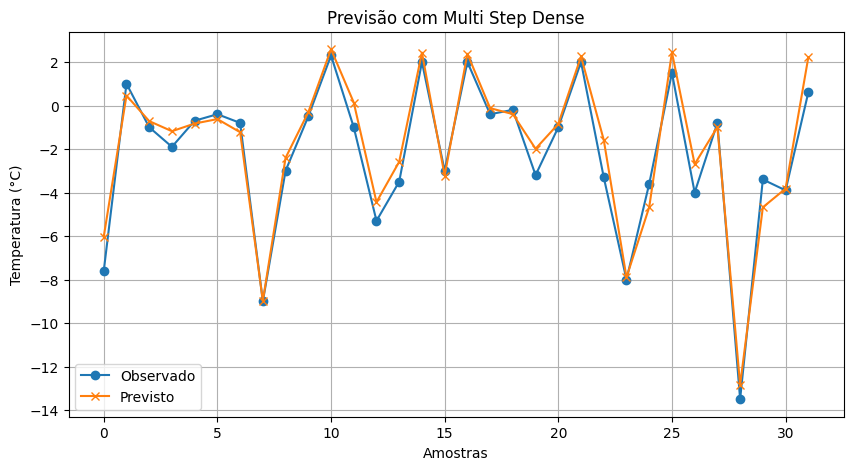

In [90]:
for inputs, labels in conv_window.test.take(1):
    # inputs: (batch, time, features) — ex: (32, 3, 15)
    predictions = multi_step_dense(inputs)

    # Remove as dimensões extras para facilitar o plot
    y_true = labels[:, 0, 0].numpy()
    y_pred = predictions[:, 0, 0].numpy()

    # Reverte a normalização (Z-score)
    y_true_orig = y_true * train_std['Air_Temp'] + train_mean['Air_Temp']
    y_pred_orig = y_pred * train_std['Air_Temp'] + train_mean['Air_Temp']

# Plotando
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_true_orig, label='Observado', marker='o')
plt.plot(y_pred_orig, label='Previsto', marker='x')
plt.title('Previsão com Multi Step Dense')
plt.xlabel('Amostras')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [91]:
#conv_window.plot(multi_step_dense)

In [92]:
print('Input shape:', wide_window.example[0].shape)
try:
  print('Output shape:', multi_step_dense(wide_window.example[0]).shape)
except Exception as e:
  print(f'\n{type(e).__name__}:{e}')

# O problema:
# input com shape (32, 24, 18) (batch de 32 janelas, cada uma com 24 passos de tempo e 18 variáveis) para um modelo Sequential que espera entrada com última dimensão = 54.
# expected axis -1 of input shape to have value 54, but received input with shape (32, 432)
# indica que, em algum lugar, o modelo foi configurado para esperar vetores de entrada de tamanho 54,
# mas está recebendo algo com shape=(32, 24, 18).

# causa:
# Você deve ter "achatado" a entrada para (batch_size, 432) dentro do modelo — usando Flatten() ou Reshape(), porque:
# 24 (time steps) × 18 (features) = 432 e isso conflita com o que o Sequential espera.

Input shape: (32, 24, 15)

ValueError:Exception encountered when calling Sequential.call().

Input 0 of layer "dense_4" is incompatible with the layer: expected axis -1 of input shape to have value 45, but received input with shape (32, 360)

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 24, 15), dtype=float32)
  • training=None
  • mask=None
  • kwargs=<class 'inspect._empty'>


In [93]:
CONV_WIDTH = 24

conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)

if modo_execucao == 'Treinamento':
  multi_step_dense = tf.keras.Sequential([
      # Shape: (time, features) => (time*features)
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(units=32, activation='relu'),
      tf.keras.layers.Dense(units=32, activation='relu'),
      tf.keras.layers.Dense(units=1),
      # Add back the time dimension.
      # Shape: (outputs) => (1, outputs)
      tf.keras.layers.Reshape([1, 1]),
  ])

  print('Input shape:', conv_window.example[0].shape)
  print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

  history = compile_and_fit(multi_step_dense, conv_window, model_name='multiple-input-step-2')
else:
  multi_step_dense = tf.keras.models.load_model(f"{lista_modelos['multiple-input-step-2']}")

#IPython.display.clear_output()
val_performance['Multi-Step-Dense-24input'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi-Step-Dense-24input'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

#conv_window.plot(multi_step_dense)

Input shape: (32, 24, 15)
Output shape: (32, 1, 1)
Epoch 1/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.1246 - mean_absolute_error: 0.2363 - mean_absolute_percentage_error: 200.8327 - mean_squared_error: 0.1246 - root_mean_squared_error: 0.3395 - val_loss: 0.0448 - val_mean_absolute_error: 0.1607 - val_mean_absolute_percentage_error: 166.5118 - val_mean_squared_error: 0.0448 - val_root_mean_squared_error: 0.2117
Epoch 2/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0408 - mean_absolute_error: 0.1391 - mean_absolute_percentage_error: 121.6648 - mean_squared_error: 0.0408 - root_mean_squared_error: 0.2019 - val_loss: 0.0401 - val_mean_absolute_error: 0.1464 - val_mean_absolute_percentage_error: 149.7163 - val_mean_squared_error: 0.0401 - val_root_mean_squared_error: 0.2002
Epoch 3/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0368 - mean_absolute_error: 0.1305 - mean_absolute_percentage_error: 113.0712 - mean_squared_error: 0.0368 - root_mean_squared_err

[-0.69406495 -0.75627232 -0.53586393 -0.62188227 -0.40640354 -0.39707028
 -0.45801922 -0.41854432  0.35327254  0.02055328  0.2850114   0.25292228
  0.37780189  0.69295145  0.06602281  0.34782598  0.09346008  0.03078533
  0.14494808  0.00682651  0.08562158  0.10298383  0.15566172  0.07536868]


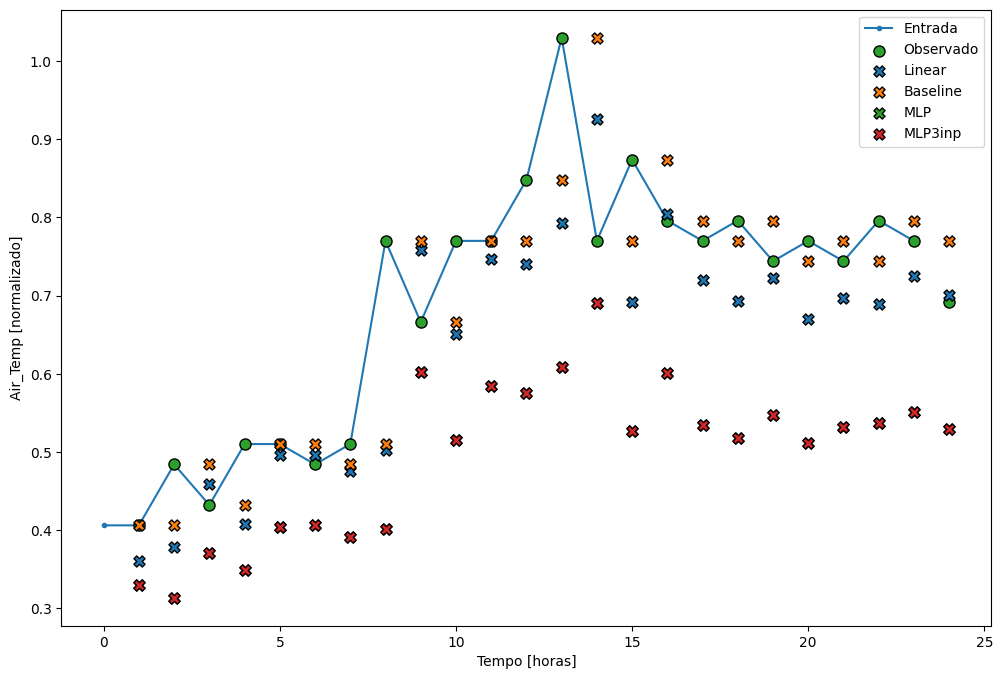

In [94]:
preds = wide_window.plot(
    models={'Linear': linear, 'Baseline': baseline, 'MLP': dense, 'MLP3inp': dense},
    plot_col='Air_Temp',
    max_subplots=1
)

# Extrair previsões do modelo Linear para o primeiro exemplo do batch
MLP3inp_preds = preds['MLP3inp'][0, :, 0]

# Usar a média e o desvio apenas da coluna Air_Temp
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# Desnormalizar
MLP3inp_preds_desnorm = MLP3inp_preds * std_temp + mean_temp
print(MLP3inp_preds_desnorm)

# Salvar como CSV (opcional)
# df_preds = pd.DataFrame({'Forecast_Linear': linear_preds_desnorm.numpy()})
# df_preds.to_csv('previsao_linear.csv', index=False)


In [95]:
datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
if modo_execucao == 'Treinamento':
  multi_step_dense.save(f"multiple-input-step-2_{datahora}.keras")

Vamos resolver o problema acima com:
## Convolution Neural Network (CNN) - METAR com Temperatura - MSE

A convolution layer `(tf.keras.layers.Conv1D)` also takes multiple time steps as input to each prediction. Below is the same model as multi_step_dense, re-written with a convolution.

Note the changes:
The `tf.keras.layers.Flatten` and the first `tf.keras.layers.Dense` are replaced by a `tf.keras.layers.Conv1D`.

The `tf.keras.layers.Reshape` is no longer necessary since the convolution keeps the time axis in its output.

In [96]:
CONV_WIDTH = 3

conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)

conv_window

if modo_execucao == 'Treinamento':
  conv_model = tf.keras.Sequential([
      tf.keras.layers.Conv1D(filters=32,
                            kernel_size=(CONV_WIDTH,),
                            activation='relu', padding='same'),
      tf.keras.layers.Dense(units=32, activation='relu'),
      tf.keras.layers.Dense(units=1),
  ])

  print("Conv model on `conv_window`")
  print('Input shape:', conv_window.example[0].shape)
  print('Output shape:', conv_model(conv_window.example[0]).shape)

  history = compile_and_fit(conv_model, conv_window, model_name='cnn')
else:
  conv_model = tf.keras.models.load_model(f"{lista_modelos['cnn']}")

Conv model on `conv_window`
Input shape: (32, 3, 15)
Output shape: (32, 3, 1)
Epoch 1/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1043 - mean_absolute_error: 0.2082 - mean_absolute_percentage_error: 166.4015 - mean_squared_error: 0.1043 - root_mean_squared_error: 0.3107 - val_loss: 0.0418 - val_mean_absolute_error: 0.1451 - val_mean_absolute_percentage_error: 137.1154 - val_mean_squared_error: 0.0418 - val_root_mean_squared_error: 0.2044
Epoch 2/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0453 - mean_absolute_error: 0.1383 - mean_absolute_percentage_error: 124.2080 - mean_squared_error: 0.0453 - root_mean_squared_error: 0.2127 - val_loss: 0.0384 - val_mean_absolute_error: 0.1372 - val_mean_absolute_percentage_error: 124.8580 - val_mean_squared_error: 0.0384 - val_root_mean_squared_error: 0.1961
Epoch 3/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0430 - mean_absolute_error: 0.1332 - mean_absolute_percentage_error: 117.3933 - mean_squared_error: 0.0

In [97]:
datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
if modo_execucao == 'Treinamento':
  conv_model.save(f"cnn_{datahora}.keras")

Train and evaluate it on the conv_window and it should give performance similar to the multi_step_dense model.

In [98]:
#IPython.display.clear_output()
val_performance['CNN-3Inp-12Out'] = conv_model.evaluate(conv_window.val, return_dict=True)
performance['CNN-3Inp-12Out'] = conv_model.evaluate(conv_window.test, verbose=0, return_dict=True)

668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0368 - mean_absolute_error: 0.1336 - mean_absolute_percentage_error: 122.0293 - mean_squared_error: 0.0368 - root_mean_squared_error: 0.1917


[-0.52654145 -0.37054796 -0.36924517 -0.22748859 -0.20813898 -0.26057058
 -0.26658412  0.62426717  0.26732893  0.57059284  0.51816113  0.69696124
  1.06521185  0.82671     0.78961145  0.72442373  0.6184307   0.64155308
  0.56433506  0.53424202  0.59878127  0.63163255  0.59407235  0.54622372]


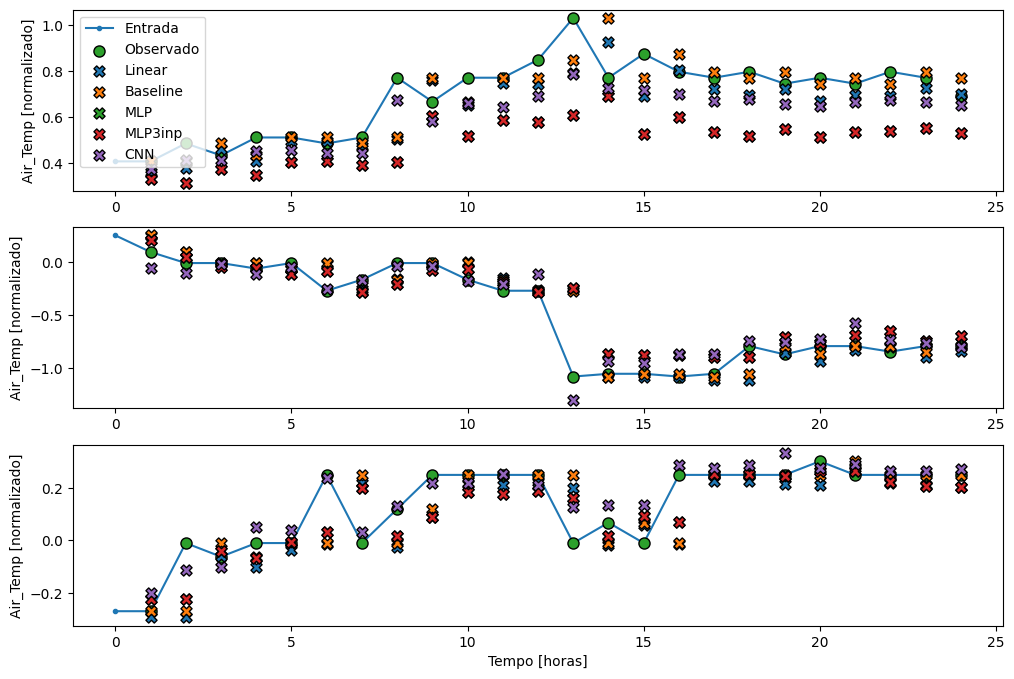

In [99]:
preds = wide_window.plot(
    models={'Linear': linear,
            'Baseline': baseline,
            'MLP': dense,
            'MLP3inp': dense,
            'CNN': conv_model},
    plot_col='Air_Temp',
    max_subplots=3
)

# Extrair previsões do modelo Linear para o primeiro exemplo do batch
conv_preds = preds['CNN'][0, :, 0]

# Usar a média e o desvio apenas da coluna Air_Temp
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# Desnormalizar
CNN_preds_desnorm = conv_preds * std_temp + mean_temp
print(CNN_preds_desnorm)

# Salvar como CSV (opcional)
# df_preds = pd.DataFrame({'Forecast_Linear': linear_preds_desnorm.numpy()})
# df_preds.to_csv('previsao_linear.csv', index=False)

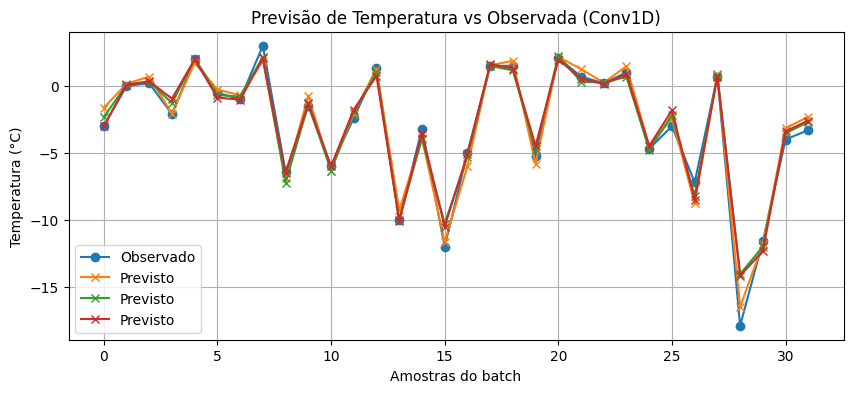

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Obter uma amostra do conjunto de teste
for inputs, labels in conv_window.test.take(1):
    predictions = conv_model(inputs)  # shape: (batch_size, 1, 1)

# Converter para 1D (batch_size,)
true = labels.numpy().squeeze()
pred = predictions.numpy().squeeze()

# Reverter normalização z-score da coluna 'Air_Temp'
true_orig = true * train_std['Air_Temp'] + train_mean['Air_Temp']
pred_orig = pred * train_std['Air_Temp'] + train_mean['Air_Temp']

# Plotar
plt.figure(figsize=(10, 4))
plt.plot(true_orig, label='Observado', marker='o')
plt.plot(pred_orig, label='Previsto', marker='x')
plt.legend()
plt.title('Previsão de Temperatura vs Observada (Conv1D)')
plt.xlabel('Amostras do batch')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()


The difference between this conv_model and the multi_step_dense model is that the conv_model can be run on inputs of any length. The convolutional layer is applied to a sliding window of inputs:

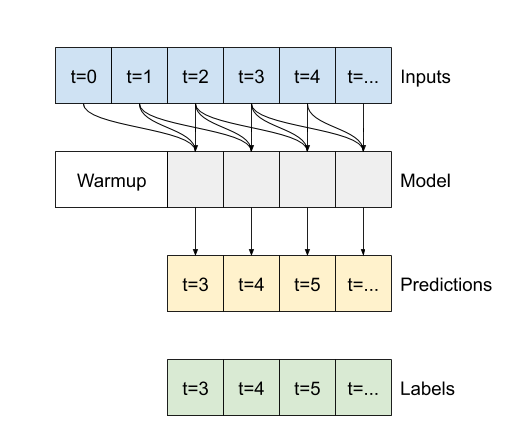

In [101]:
print("Wide window")
print('Input shape:', wide_window.example[0].shape)
print('Labels shape:', wide_window.example[1].shape)
print('Output shape:', conv_model(wide_window.example[0]).shape)

Wide window
Input shape: (32, 24, 15)
Labels shape: (32, 24, 1)
Output shape: (32, 24, 1)


Observe que a saída é maior que a entrada. Para que o treinamento ou a plotagem funcionem, é necessário que os rótulos e a previsão tenham o mesmo comprimento. Portanto, crie um WindowGenerator para produzir janelas amplas com alguns passos de tempo de entrada extras para que os comprimentos dos rótulos e da previsão correspondam:

In [102]:
#wide_conv_window.plot(conv_model)

## Recurrent Neural Network (RNN) - LSTM - METAR com Temperatura - MSE

A Recurrent Neural Network (RNN) is a type of neural network well-suited to time series data. RNNs process a time series step-by-step, maintaining an internal state from time-step to time-step.

You can learn more in the Text generation with an RNN tutorial and the Recurrent Neural Networks (RNN) with Keras guide.

In this tutorial, you will use an RNN layer called Long Short-Term Memory (tf.keras.layers.LSTM).

An important constructor argument for all Keras RNN layers, such as tf.keras.layers.LSTM, is the return_sequences argument. This setting can configure the layer in one of two ways:

* **If False**, the default, the layer only returns the output of the final time step, giving the model time to warm up its internal state before making a single prediction:

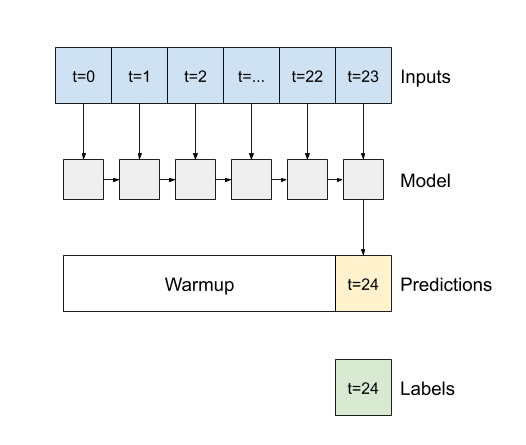

*** the layer returns** an output for each input. This is useful for:
Stacking RNN layers.
Training a model on multiple time steps simultaneously.

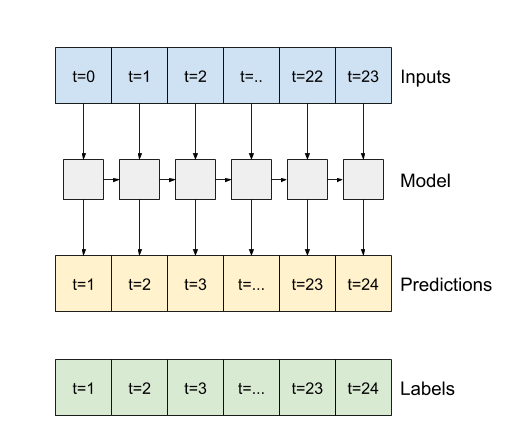

In [103]:
modelo = 'LSTM'

LABEL_WIDTH = 12
CONV_WIDTH = 3
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)  # = 12 + (3 - 1) = 14

wide_conv_window = WindowGenerator(
    input_width=LABEL_WIDTH,      # 14
    label_width=INPUT_WIDTH,      # 12
    shift=1,                      # Previsão começa 1 hora após o fim do input
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['Air_Temp']
)

if modo_execucao == 'Treinamento':
  LSTM_fit_start = time.time()
  lstm_model = tf.keras.models.Sequential([
      # Shape [batch, time, features] => [batch, time, lstm_units]
      tf.keras.layers.LSTM(32, return_sequences=False),
      # Shape => [batch, time, features]
      tf.keras.layers.Dense(units=24),
      tf.keras.layers.Reshape([24, 1])
  ])

  print('Input shape:', wide_window.example[0].shape)
  print('Output shape:', lstm_model(wide_window.example[0]).shape)

  history = compile_and_fit(lstm_model, wide_window, model_name='LSTM')
  LSTM_fit_end = time.time()
  LSTM_fit_elapsed = LSTM_fit_end - LSTM_fit_start
  tempos_treinamento[modelo] = LSTM_fit_elapsed
else:
  # ATENÇÃO! Aqui estou carregando um modelo já treinado, pois estamos em modo de 'Visualização'
  # O tempo será divergente no caso de comparação com modo 'Treinamento'.
  lstm_model = tf.keras.models.load_model(f"{lista_modelos['LSTM']}")

#IPython.display.clear_output()

LSTM_val_start = time.time()
val_performance['LSTM-48Inp-12Out'] = lstm_model.evaluate(wide_window.val, return_dict=True)
LSTM_val_end = time.time()
LSTM_val_elapsed = LSTM_val_end - LSTM_val_start
tempos_validacao[modelo] = LSTM_val_elapsed

LSTM_test_start = time.time()
performance['LSTM-48Inp-12Out'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)
LSTM_test_end = time.time()
LSTM_test_elapsed = LSTM_test_end - LSTM_test_start
tempos_teste[modelo] = LSTM_test_elapsed

Input shape: (32, 24, 15)
Output shape: (32, 24, 1)
Epoch 1/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.2060 - mean_absolute_error: 0.2782 - mean_absolute_percentage_error: 196.6293 - mean_squared_error: 0.2060 - root_mean_squared_error: 0.4271 - val_loss: 0.0215 - val_mean_absolute_error: 0.1052 - val_mean_absolute_percentage_error: 91.5958 - val_mean_squared_error: 0.0215 - val_root_mean_squared_error: 0.1467
Epoch 2/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - loss: 0.0252 - mean_absolute_error: 0.1052 - mean_absolute_percentage_error: 90.3986 - mean_squared_error: 0.0252 - root_mean_squared_error: 0.1587 - val_loss: 0.0165 - val_mean_absolute_error: 0.0903 - val_mean_absolute_percentage_error: 77.8473 - val_mean_squared_error: 0.0165 - val_root_mean_squared_error: 0.1284
Epoch 3/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - loss: 0.0182 - mean_absolute_error: 0.0888 - mean_absolute_percentage_error: 76.5904 - mean_squared_error: 0.0182 - root_mean_squared_error

In [104]:
datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
if modo_execucao == 'Treinamento':
  lstm_model.save(f"LSTM_{datahora}.keras")

In [105]:
#wide_window.plot(lstm_model)

In [106]:
example_inputs, example_labels = wide_window.example

for name, model in {
    'Baseline': baseline,
    'Linear': linear,
    'Dense': dense,
    'CNN': conv_model,
    'LSTM': lstm_model
}.items():
    predictions = model(example_inputs)
    print(f"{name}: predictions shape = {predictions.shape}, labels shape = {example_labels.shape}")


Baseline: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
Linear: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
Dense: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
CNN: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
LSTM: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)


[-0.30271099 -0.14494584 -0.27100342 -0.0494574   0.01301048 -0.08233126
  0.2271643   0.72148463  0.93882281  0.77042735  1.00913229  1.43593943
  1.60840957  1.42190573  1.11065502  1.10660328  1.12575071  0.97995935
  0.95523562  0.98081366  0.9143565   1.09306401  0.97730174  0.65773757]


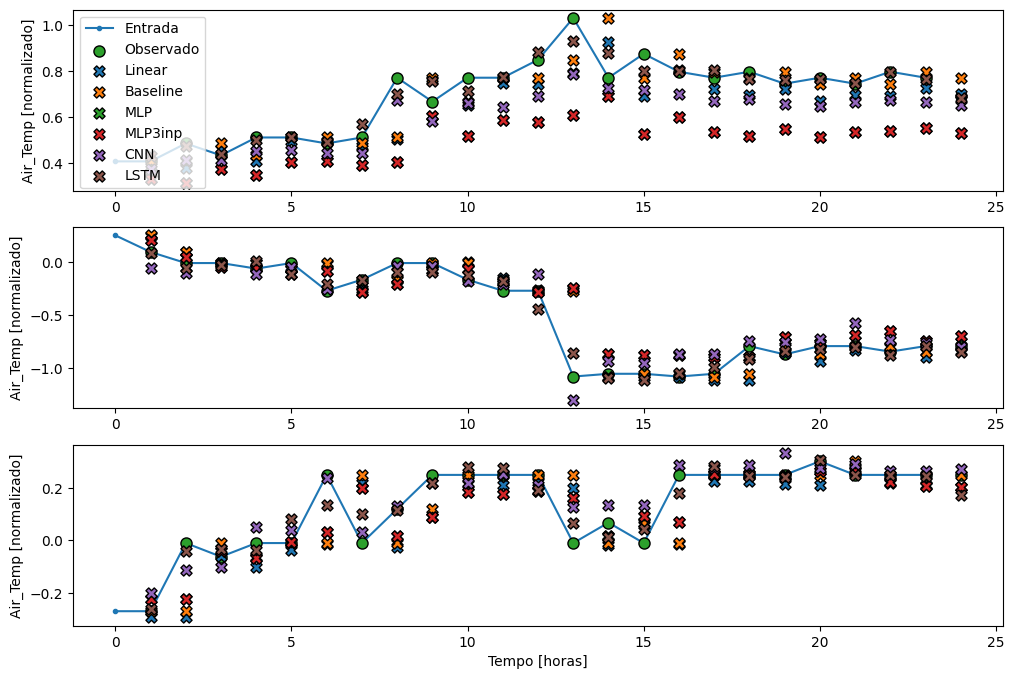

In [107]:
preds = wide_window.plot(
    models={'Linear': linear,
            'Baseline': baseline,
            'MLP': dense,
            'MLP3inp': dense,
            'CNN': conv_model,
            'LSTM':lstm_model},
    plot_col='Air_Temp',
    max_subplots=3
)

# Extrair previsões do modelo Linear para o primeiro exemplo do batch
lstm_preds = preds['LSTM'][0, :, 0]

# Usar a média e o desvio apenas da coluna Air_Temp
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# Desnormalizar
lstm_preds_desnorm = lstm_preds * std_temp + mean_temp
print(lstm_preds_desnorm)

# Salvar como CSV (opcional)
# df_preds = pd.DataFrame({'Forecast_Linear': linear_preds_desnorm.numpy()})
# df_preds.to_csv('previsao_linear.csv', index=False)

In [108]:
cm = lstm_model.metrics[1]
cm.metrics

val_performance

{'Baseline': {'loss': 0.036186959594488144,
  'mean_absolute_error': 0.11897344887256622},
 'Linear': {'loss': 0.034997642040252686,
  'mean_absolute_error': 0.12375885248184204,
  'mean_absolute_percentage_error': 108.71046447753906,
  'mean_squared_error': 0.034997642040252686,
  'root_mean_squared_error': 0.18707656860351562},
 'Dense': {'loss': 0.054526444524526596,
  'mean_absolute_error': 0.1607581228017807,
  'mean_absolute_percentage_error': 104.21866607666016,
  'mean_squared_error': 0.04998483136296272,
  'root_mean_squared_error': 0.22357288002967834},
 'Multi Step dense': {'loss': 0.035390596836805344,
  'mean_absolute_error': 0.1323683261871338,
  'mean_absolute_percentage_error': 123.46326446533203,
  'mean_squared_error': 0.035390596836805344,
  'root_mean_squared_error': 0.188123881816864},
 'Multi-Step-Dense-24input': {'loss': 0.035625159740448,
  'mean_absolute_error': 0.13396286964416504,
  'mean_absolute_percentage_error': 122.3671875,
  'mean_squared_error': 0.0356

In [109]:
# x = np.arange(len(performance))
# width = 0.3
metric_name = 'mean_absolute_error'
# val_mae = [v[metric_name] for v in val_performance.values()]
# test_mae = [v[metric_name] for v in performance.values()]

# plt.ylabel('MAE - Mean_Absolute_Error [Temperatura (degC), normalizado]')
# plt.bar(x - 0.17, val_mae, width, label='Validação')
# plt.bar(x + 0.17, test_mae, width, label='Teste')
# plt.xticks(ticks=x, labels=performance.keys(),
#            rotation=90)
# _ = plt.legend()

for name, value in performance.items():
  print(f'{name:12s}: {value[metric_name]:0.4f}')

Baseline    : 0.1068
Linear      : 0.1160
Dense       : 0.1682
Multi Step dense: 0.1348
Multi-Step-Dense-24input: 0.1495
CNN-3Inp-12Out: 0.1374
LSTM-48Inp-12Out: 0.0485


Avaliação do gráfico:
Baseline	MAEval=~0.10	MAEtest=~0.117	Muito forte! O modelo que apenas repete a última temperatura já é bom.

Linear	~0.105	~0.121	Levemente melhor que o Baseline no Val, igual ou um pouco pior no Teste.

Dense	~0.11	~0.118	Não superou o Linear, possivelmente subajuste ou ruído.

Multi-step Dense	~0.108	~0.120	Similar ao Dense.

Conv	~0.11	~0.120	Também não ganhou vantagem, talvez porque a estrutura temporal é simples.

LSTM	~0.105	~0.122	Leve overfitting, mas desempenho similar ao Linear.


Baseline já é muito forte, então superar ele é difícil — especialmente se a temperatura varia pouco de um passo para o outro (ex: hora a hora ou 3h em 3h).

Modelos mais complexos não trouxeram ganho claro — isso pode indicar que:

As janelas são curtas (pouca informação sequencial);
Os dados são limpos e suaves;
O target tem pouca variabilidade.
Seu Linear model está praticamente no mesmo nível dos outros, o que é um ótimo sinal de que seu pipeline de predição está funcionando bem — e que a tarefa em si pode não precisar de redes profundas.

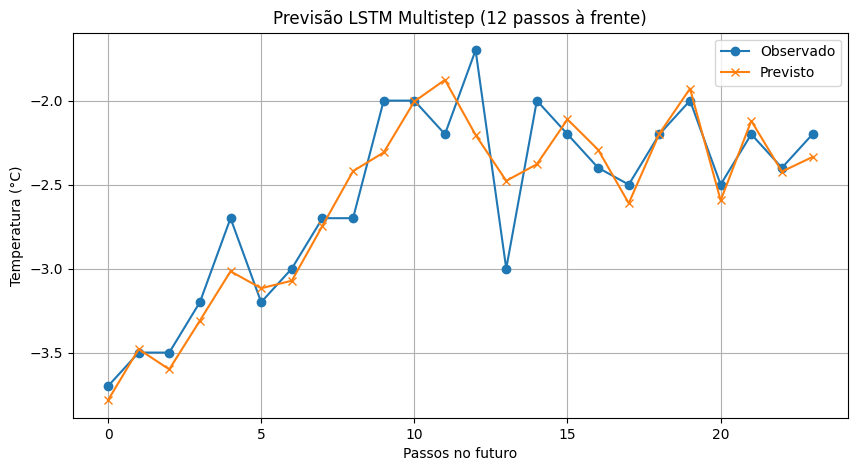

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# Obter um batch do conjunto de teste
for inputs, labels in wide_window.test.take(1):
    predictions = lstm_model(inputs)

# true e pred têm shape (batch_size, 12, 1)
# Selecionar a primeira amostra do batch para plotar
true = labels[0].numpy().squeeze()       # shape (12,)
pred = predictions[0].numpy().squeeze()  # shape (12,)

# Reverter normalização z-score para a coluna 'Air_Temp'
true_orig = true * train_std['Air_Temp'] + train_mean['Air_Temp']
pred_orig = pred * train_std['Air_Temp'] + train_mean['Air_Temp']

# Plot dos 12 passos à frente
plt.figure(figsize=(10, 5))
plt.plot(true_orig, label='Observado', marker='o')
plt.plot(pred_orig, label='Previsto', marker='x')
plt.title('Previsão LSTM Multistep (12 passos à frente)')
plt.xlabel('Passos no futuro')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()

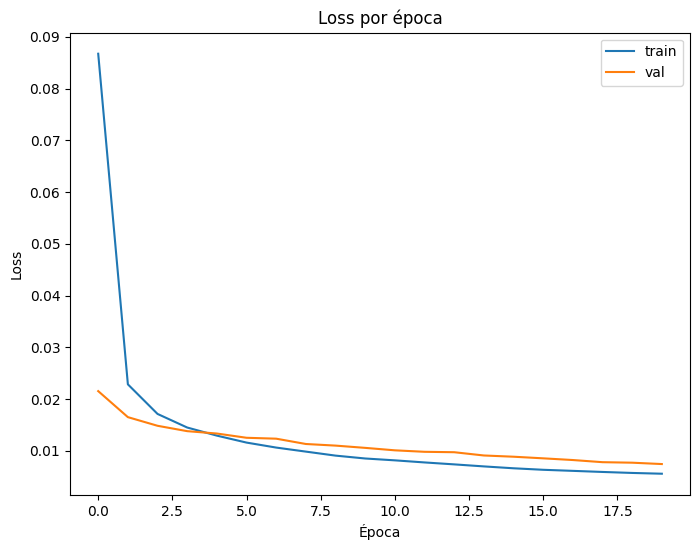

In [111]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.show()


Multi-output models
The models so far all predicted a single output feature, T (degC), for a single time step.

All of these models can be converted to predict multiple features just by changing the number of units in the output layer and adjusting the training windows to include all features in the labels (example_labels):

## Recurrent Neural Network (RNN) - BiLSTM - METAR com Temperatura - MSE

In [112]:
import time
import tensorflow as tf

start_time = time.time()
label_width=24
wide_window = WindowGenerator(
    input_width=24,
    label_width=24,
    shift=1,
    label_columns=['Air_Temp'],
    train_df=train_df,
    val_df=val_df,
    test_df=test_df
)


if modo_execucao == 'Treinamento':
  # Modelo BiLSTM
  bilstm_model = tf.keras.models.Sequential([
      # Bidirectional LSTM
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False)),
      # Densa para saída
      tf.keras.layers.Dense(units=label_width),
      tf.keras.layers.Reshape([label_width, 1])
  ])

  print('Input shape:', wide_window.example[0].shape)
  print('Output shape:', bilstm_model(wide_window.example[0]).shape)

  history = compile_and_fit(bilstm_model, wide_window, model_name='BiLSTM')
else:
  bilstm_model = tf.keras.models.load_model(f"{lista_modelos['BiLSTM']}")

# Validação e teste
tempo_inicio_validacao = time.time()
val_performance['BiLSTM-48Inp-12Out'] = bilstm_model.evaluate(wide_window.val, return_dict=True)
tempo_fim_validacao = time.time()
duracao_validacao = tempo_fim_validacao - tempo_inicio_validacao
print(f"Tempo de validação do BiLSTM: {duracao_validacao:.2f} segundos")

performance['BiLSTM-48Inp-12Out'] = bilstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

end_time = time.time()
execution_time = end_time - start_time

print(f"Tempo de execução do BiLSTM: {execution_time:.2f} segundos")

Input shape: (32, 24, 15)
Output shape: (32, 24, 1)
Epoch 1/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 0.1337 - mean_absolute_error: 0.2201 - mean_absolute_percentage_error: 167.0313 - mean_squared_error: 0.1337 - root_mean_squared_error: 0.3414 - val_loss: 0.0172 - val_mean_absolute_error: 0.0923 - val_mean_absolute_percentage_error: 77.0111 - val_mean_squared_error: 0.0172 - val_root_mean_squared_error: 0.1312
Epoch 2/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 0.0172 - mean_absolute_error: 0.0863 - mean_absolute_percentage_error: 74.2236 - mean_squared_error: 0.0172 - root_mean_squared_error: 0.1310 - val_loss: 0.0137 - val_mean_absolute_error: 0.0802 - val_mean_absolute_percentage_error: 68.4153 - val_mean_squared_error: 0.0137 - val_root_mean_squared_error: 0.1171
Epoch 3/20
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 0.0125 - mean_absolute_error: 0.0733 - mean_absolute_percentage_error: 63.1539 - mean_squared_error: 0.0125 - root_mean_squared_err

In [113]:
datahora = datetime.datetime.now().strftime("%d-%m-%Y_%H%M%SZ")
if modo_execucao == 'Treinamento':
  bilstm_model.save(f"BiLSTM_{datahora}.keras")

In [114]:
example_inputs, example_labels = wide_window.example

for name, model in {
    'Baseline': baseline,
    'Linear': linear,
    'Dense': dense,
    'CNN': conv_model,
    'LSTM': lstm_model,
    'BiLSTM': bilstm_model
}.items():
    predictions = model(example_inputs)
    print(f"{name}: predictions shape = {predictions.shape}, labels shape = {example_labels.shape}")


Baseline: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
Linear: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
Dense: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
CNN: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
LSTM: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)
BiLSTM: predictions shape = (32, 24, 1), labels shape = (32, 24, 1)


[-1.96728577 -1.97600523 -1.9777225  -2.00248127 -1.9827297  -1.93464819
 -2.00306817 -2.01328998 -0.95429333 -1.00386715 -0.94387046 -1.51234554
 -1.95389468 -1.93376549 -1.9870691  -0.99547434 -1.99815883 -1.91040424
 -1.99467269 -1.91570252 -2.93161329 -2.9691461  -2.99798197 -3.015723  ]


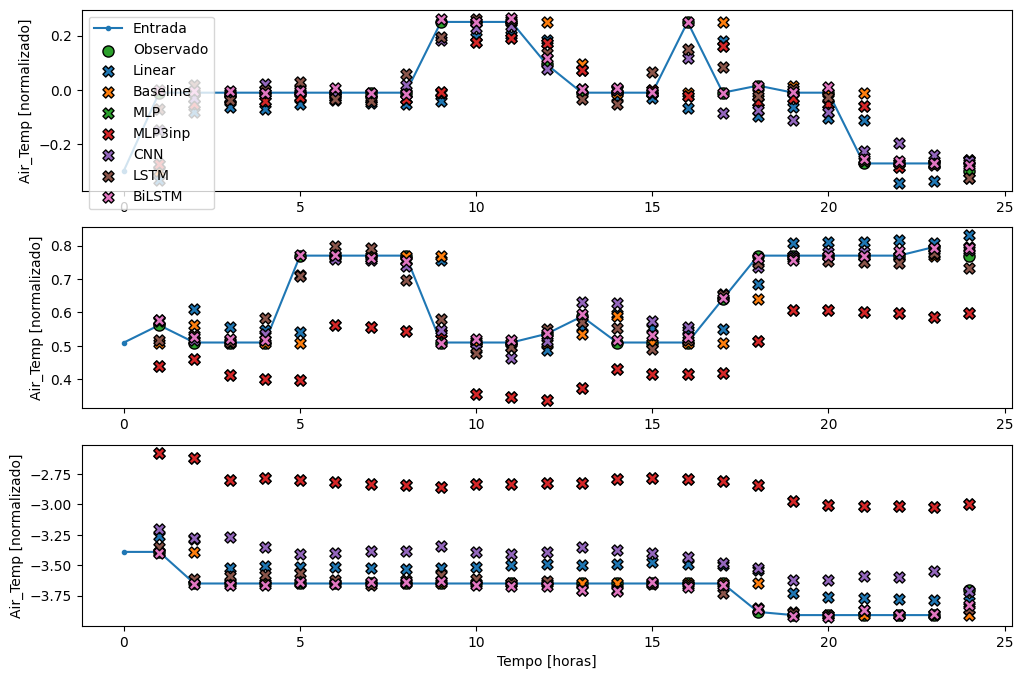

In [115]:
preds = wide_window.plot(
    models={'Linear': linear,
            'Baseline': baseline,
            'MLP': dense,
            'MLP3inp': dense,
            'CNN': conv_model,
            'LSTM':lstm_model,
            'BiLSTM': bilstm_model},
    plot_col='Air_Temp',
    max_subplots=3
)

# Extrair previsões do modelo Linear para o primeiro exemplo do batch
bilstm_preds = preds['BiLSTM'][0, :, 0]

# Usar a média e o desvio apenas da coluna Air_Temp
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# Desnormalizar
bilstm_preds_desnorm = bilstm_preds * std_temp + mean_temp
print(bilstm_preds_desnorm)

# Salvar como CSV (opcional)
# df_preds = pd.DataFrame({'Forecast_Linear': linear_preds_desnorm.numpy()})
# df_preds.to_csv('previsao_linear.csv', index=False)

In [116]:
# Extrair um batch do conjunto de teste
for batch_inputs, batch_labels in wide_window.test.take(1):
    print("Inputs shape:", batch_inputs.shape)   # (batch_size, input_width, features)
    print("Labels shape:", batch_labels.shape)   # (batch_size, label_width, features)

    # Converter para numpy arrays
    inputs_np = batch_inputs.numpy()
    labels_np = batch_labels.numpy()

    # Suponha que você tenha guardado as médias e desvios
mean_temp = train_df['Air_Temp'].mean()
std_temp = train_df['Air_Temp'].std()

# Reverter a normalização
true_labels = labels_np * std_temp + mean_temp
predicted_labels = inputs_np * std_temp + mean_temp


Inputs shape: (32, 24, 15)
Labels shape: (32, 24, 1)


In [117]:
# Pegue o primeiro batch do teste
for example_inputs, example_labels in wide_window.test.take(1):
    inputs_np = example_inputs.numpy()
    labels_np = example_labels.numpy()
    break

# Pegar índices temporais do batch
batch_index = wide_window.label_indices[:labels_np.shape[1]]

# Converter para timestamps reais
timestamps = test_df.index[batch_index]

# Conferir timestamps obtidos
print(timestamps)


DatetimeIndex(['2024-04-09 05:00:00', '2024-04-09 06:00:00',
               '2024-04-09 07:00:00', '2024-04-09 08:00:00',
               '2024-04-09 09:00:00', '2024-04-09 10:00:00',
               '2024-04-09 11:00:00', '2024-04-09 12:00:00',
               '2024-04-09 13:00:00', '2024-04-09 14:00:00',
               '2024-04-09 15:00:00', '2024-04-09 16:00:00',
               '2024-04-09 17:00:00', '2024-04-09 18:00:00',
               '2024-04-09 19:00:00', '2024-04-09 20:00:00',
               '2024-04-09 21:00:00', '2024-04-09 22:00:00',
               '2024-04-09 23:00:00', '2024-04-10 00:00:00',
               '2024-04-10 01:00:00', '2024-04-10 02:00:00',
               '2024-04-10 03:00:00', '2024-04-10 04:00:00'],
              dtype='datetime64[ns]', name='time', freq=None)


In [118]:
import pandas as pd

# Extrair um batch
for batch_inputs, batch_labels in wide_window.test.take(1):
    labels_np = batch_labels.numpy().squeeze()  # (batch, steps) → (batch, 12)
    break

# Desnormalizar (se necessário)
labels_np = labels_np * std_temp + mean_temp

# Criar DataFrame
df_labels = pd.DataFrame(labels_np, columns=[f'Hour+{i+1}' for i in range(labels_np.shape[1])])

# Salvar como CSV
df_labels.to_csv("labels_temperatura_teste.csv", index=False)
print(df_labels)


      Hour+1    Hour+2    Hour+3    Hour+4    Hour+5    Hour+6    Hour+7  \
0   0.952076  0.926073  0.952076  0.900070  0.822061  0.770055  0.770055   
1   0.249996  0.328005  0.249996  0.249996  0.275999  0.249996  0.249996   
2  -0.140048 -0.270063 -0.270063 -0.244060 -0.270063 -0.270063 -0.270063   
3   0.822061  0.770055  0.744052  0.458020  0.458020  0.458020  0.510026   
4   1.030084  1.056087  1.030084  1.030084  0.926073  1.030084  0.770055   
5  -0.400077 -0.400077 -0.270063 -0.348071 -0.400077 -0.400077 -0.452083   
6  -1.804236 -1.882245 -2.090269 -2.090269 -1.934251 -1.804236 -1.830239   
7  -0.218057 -0.270063 -0.270063 -0.218057 -0.270063 -0.010033 -0.036036   
8   0.041973 -0.010033 -0.062039 -0.088042 -0.062039  0.041973 -0.010033   
9  -2.480313 -2.350298 -2.428307 -2.350298 -2.350298 -2.272289 -2.142274   
10  0.223993  0.223993  0.510026  0.458020  0.380011  0.354008  0.380011   
11 -0.972142 -1.180166 -1.882245 -2.012260 -2.116271 -1.934251 -1.856242   
12 -2.012260

In [119]:
preds = model.predict(wide_window.test)
preds = preds.squeeze() * std_temp + mean_temp  # desnormaliza

df_preds = pd.DataFrame(preds, columns=[f'Hour+{i+1}' for i in range(preds.shape[1])])
df_preds.to_csv("previsoes_modelo.csv", index=False)
print(df_preds)


334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
         Hour+1    Hour+2    Hour+3    Hour+4    Hour+5    Hour+6    Hour+7  \
0     -0.295516 -0.321035 -0.297289 -0.471423 -0.404803 -0.500497 -0.663059   
1     -0.536284 -0.475929 -0.408463 -0.703702 -0.741204 -1.039990 -1.199353   
2      0.785486  0.797622  0.768114  0.809533  0.800509  0.745564  0.732056   
3     -0.473179 -0.345978 -0.108635 -0.003418  0.074896  0.163090  0.244529   
4      0.256469  0.251785  0.192906  0.231642  0.103965  0.067780  0.111618   
...         ...       ...       ...       ...       ...       ...       ...   
10655  0.311839  0.303985  0.257929  0.431340  0.515974  0.607655  0.527315   
10656  0.230536  0.252296  0.245030  0.243576  0.252563  0.262001  0.219872   
10657  0.265411  0.306370  0.499907  0.499263  0.506994  0.522519  0.508929   
10658  1.047571  0.767220  0.681287  0.773566  0.780789  0.836340  1.017360   
10659  0.781606  0.738867  0.688808  0.677910  0.686065  0.764479  0.757739   

         H

In [120]:
import pandas as pd
import numpy as np

# Simula um índice de datas com frequência horária por 2 anos
date_range = pd.date_range(start="2025-03-01", end="2025-06-30", freq="h")

# Simula valores de temperatura
np.random.seed(42)
temp_values = 10 + 5 * np.random.randn(len(date_range))
test_df = pd.DataFrame({"Air_Temp": temp_values}, index=date_range)

# Configuração da janela
input_width = 24
shift = 12
label_width = 12

# Ponto de início das labels considerando a janela
start_index = input_width + shift - 1
timestamps_labels = test_df.index[start_index:start_index + label_width]
timestamps_labels.name = "Data_Hora"

# Cria DataFrame com os timestamps das labels
timestamps_labels_df = pd.DataFrame(timestamps_labels)

# Mostra a tabela no Colab
from IPython.display import display
display(timestamps_labels_df)


,Data_Hora
0,2025-03-02 11:00:00
1,2025-03-02 12:00:00
2,2025-03-02 13:00:00
3,2025-03-02 14:00:00
4,2025-03-02 15:00:00
5,2025-03-02 16:00:00
6,2025-03-02 17:00:00
7,2025-03-02 18:00:00
8,2025-03-02 19:00:00
9,2025-03-02 20:00:00


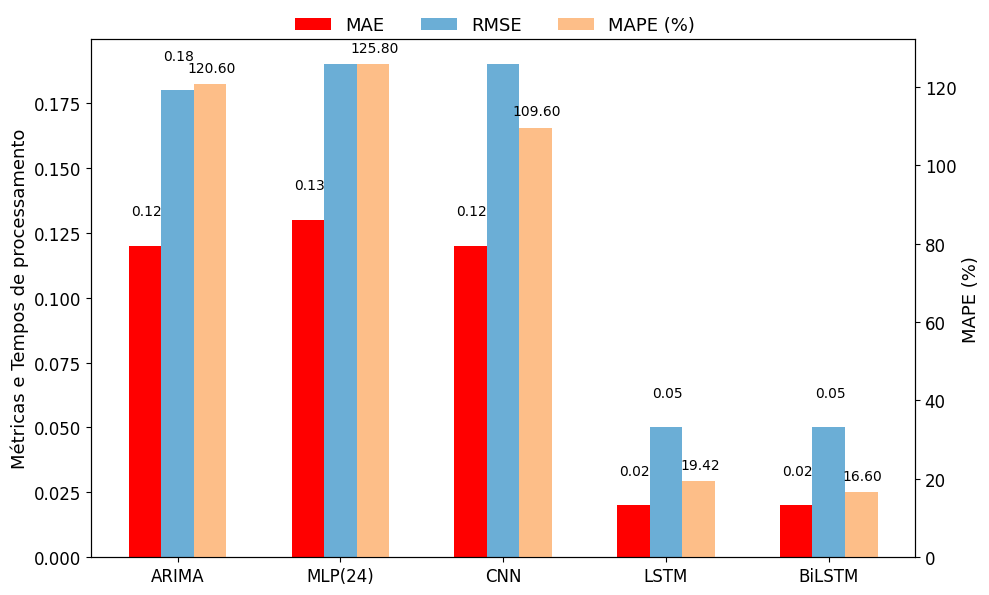

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# Dados dos modelos
modelos = ['ARIMA', 'MLP(24)', 'CNN', 'LSTM', 'BiLSTM']
mae =   [0.12, 0.13, 0.12, 0.02, 0.02]
mape =  [120.6, 125.8, 109.6, 19.42, 16.6]
rmse =  [0.18, 0.19, 0.19, 0.05, 0.05]

x = np.arange(len(modelos))
largura = 0.20

fig, ax1 = plt.subplots(figsize=(10, 6))

bar_mae = ax1.bar(x - largura, mae, largura, label='MAE', color='red')
bar_rmse = ax1.bar(x, rmse, largura, label='RMSE', color='#6baed6')
ax1.set_ylabel('Métricas e Tempos de processamento', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

ax2 = ax1.twinx()
bar_mape = ax2.bar(x + largura, mape, largura, label='MAPE (%)', color='#fdae6b', alpha=0.8)
ax2.set_ylabel('MAPE (%)', fontsize=13)
ax2.tick_params(axis='y', labelsize=12)

# Legenda afastada para cima
labels = ['MAE', 'RMSE', 'MAPE (%)']
fig.legend([bar_mae, bar_rmse, bar_mape], labels, loc='upper center', ncol=3, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.00))

# Adiciona valores "dentro" das barras
def autolabel(bars, ax, fmt='{:.2f}', y_offset=0.01):
    """Adiciona valores nas barras."""
    for bar in bars:
        for rect in bar:
            height = rect.get_height()
            ax.annotate(fmt.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height + y_offset),
                        xytext=(1, 1),  # Pequeno deslocamento vertical
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, color='black')

autolabel([bar_mae], ax1, fmt='{:.2f}')
autolabel([bar_rmse], ax1, fmt='{:.2f}')
autolabel([bar_mape], ax2, fmt='{:.2f}', y_offset=2.0)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Deixa espaço para a legenda acima
plt.show()


In [122]:
#wide_window.plot(bilstm_model)

In [123]:
val_performance

{'Baseline': {'loss': 0.036186959594488144,
  'mean_absolute_error': 0.11897344887256622},
 'Linear': {'loss': 0.034997642040252686,
  'mean_absolute_error': 0.12375885248184204,
  'mean_absolute_percentage_error': 108.71046447753906,
  'mean_squared_error': 0.034997642040252686,
  'root_mean_squared_error': 0.18707656860351562},
 'Dense': {'loss': 0.054526444524526596,
  'mean_absolute_error': 0.1607581228017807,
  'mean_absolute_percentage_error': 104.21866607666016,
  'mean_squared_error': 0.04998483136296272,
  'root_mean_squared_error': 0.22357288002967834},
 'Multi Step dense': {'loss': 0.035390596836805344,
  'mean_absolute_error': 0.1323683261871338,
  'mean_absolute_percentage_error': 123.46326446533203,
  'mean_squared_error': 0.035390596836805344,
  'root_mean_squared_error': 0.188123881816864},
 'Multi-Step-Dense-24input': {'loss': 0.035625159740448,
  'mean_absolute_error': 0.13396286964416504,
  'mean_absolute_percentage_error': 122.3671875,
  'mean_squared_error': 0.0356

In [124]:
performance

{'Baseline': {'loss': 0.0319359116256237,
  'mean_absolute_error': 0.10684743523597717},
 'Linear': {'loss': 0.03131533041596413,
  'mean_absolute_error': 0.11595908552408218,
  'mean_absolute_percentage_error': 72.5048828125,
  'mean_squared_error': 0.03131533041596413,
  'root_mean_squared_error': 0.17696137726306915},
 'Dense': {'loss': 0.06667996197938919,
  'mean_absolute_error': 0.16817380487918854,
  'mean_absolute_percentage_error': 73.98884582519531,
  'mean_squared_error': 0.06213835999369621,
  'root_mean_squared_error': 0.24927566945552826},
 'Multi Step dense': {'loss': 0.0366043746471405,
  'mean_absolute_error': 0.13484720885753632,
  'mean_absolute_percentage_error': 81.956298828125,
  'mean_squared_error': 0.0366043746471405,
  'root_mean_squared_error': 0.1913226991891861},
 'Multi-Step-Dense-24input': {'loss': 0.04344356060028076,
  'mean_absolute_error': 0.14946307241916656,
  'mean_absolute_percentage_error': 91.2537841796875,
  'mean_squared_error': 0.043443560600

In [125]:
#wide_window.plot(bilstm_model)

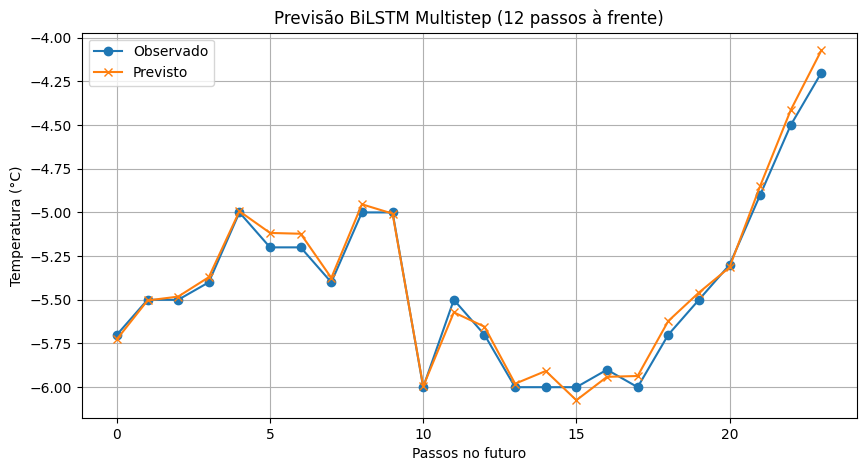

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# Obter um batch do conjunto de teste
for inputs, labels in wide_window.test.take(1):
    predictions = bilstm_model(inputs)

# Selecionar a primeira amostra do batch para visualização
true = labels[0].numpy().squeeze()       # shape (12,)
pred = predictions[0].numpy().squeeze()  # shape (12,)

# Reverter normalização z-score para 'Air_Temp'
true_orig = true * train_std['Air_Temp'] + train_mean['Air_Temp']
pred_orig = pred * train_std['Air_Temp'] + train_mean['Air_Temp']

# Plotar os 12 passos à frente
plt.figure(figsize=(10, 5))
plt.plot(true_orig, label='Observado', marker='o')
plt.plot(pred_orig, label='Previsto', marker='x')
plt.title('Previsão BiLSTM Multistep (12 passos à frente)')
plt.xlabel('Passos no futuro')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()


In [127]:
modelos = {
    'BiLSTM': (bilstm_model, wide_window),
    'LSTM': (lstm_model, wide_window),
    'CNN': (conv_model, conv_window),
    'Dense': (dense, single_step_window),
    'MultiStepDense': (multi_step_dense, conv_window),
    'Linear': (linear, single_step_window),
    'Baseline': (baseline, wide_window)
}

In [129]:
for nome, (model, window) in modelos.items():
    for x, y in window.test.take(1):
        print(f'{nome}: input shape = {x.shape}')

BiLSTM: input shape = (32, 24, 15)
LSTM: input shape = (32, 24, 15)
CNN: input shape = (32, 3, 15)
Dense: input shape = (32, 1, 15)
MultiStepDense: input shape = (32, 3, 15)
Linear: input shape = (32, 1, 15)
Baseline: input shape = (32, 24, 15)


Escolhi aqui o batch que queria ver, aleatoriamente:

Corrigido o uso incorreto do start_time e timestamps: agora eles refletem corretamente o tempo do batch batch_index.

Garantido que os dados estão desnormalizados corretamente com mean_temp e std_temp.

Tornado o script flexível: basta mudar batch_index = X no início do script para gerar a tabela para qualquer batch.

In [139]:
total_batches = sum(1 for _ in wide_window.test)
print("Total de batches no conjunto de teste:", total_batches)


Total de batches no conjunto de teste: 334


In [138]:
import pandas as pd
import numpy as np
import itertools

# === 1. Defina o índice do batch desejado ==

batch_index = 78  # Altere aqui para outro batch

# === 2. Parâmetros do Window ===
label_width = wide_window.label_width
total_window_size = wide_window.total_window_size

# === 3. Estatísticas de normalização ===
mean_temp = train_mean['Air_Temp']
std_temp = train_std['Air_Temp']

# === 4. Extrair batch específico ===
inputs, labels = list(itertools.islice(wide_window.test, batch_index, batch_index + 1))[0]

# === 5. Calcular o índice de início da janela no df de teste ===
label_start_idx = batch_index + total_window_size - label_width
timestamps = wide_window.test_df.index[label_start_idx : label_start_idx + label_width]

# === 6. Dicionário de modelos ===
models = {
    'Baseline': baseline,
    'Linear': linear,
    'MLP': dense,
    'MLP3inp': dense,
    'CNN': conv_model,
    'LSTM': lstm_model,
    'BiLSTM': bilstm_model
}

# === 7. Criar dicionário de dados para o DataFrame ===
data = {'Timestamp': timestamps}

# Série observada (desnormalizada)
data['Observado'] = (labels[0, :, 0].numpy() * std_temp) + mean_temp

# Adicionar as previsões desnormalizadas de cada modelo
for name, model in models.items():
    preds = model(inputs)
    preds_np = preds[0, :, 0].numpy()
    data[f'Previsao_{name}'] = preds_np * std_temp + mean_temp

# === 8. Criar DataFrame final ===
df_comparacao = pd.DataFrame(data)

# === 9. Salvar como CSV ===
df_comparacao.to_csv(f'comparacao_modelos_batch{batch_index}.csv', index=False)

# === 10. Visualizar resultado ===
print(f"\nBatch {batch_index} - comparação entre modelos:")
print(df_comparacao)




Batch 78 - comparação entre modelos:
             Timestamp  Observado  Previsao_Baseline  Previsao_Linear  \
0  2024-04-12 11:00:00        0.5                0.2         0.594183   
1  2024-04-12 12:00:00        1.1                0.5         0.671934   
2  2024-04-12 13:00:00        1.5                1.1         1.228544   
3  2024-04-12 14:00:00        1.5                1.5         1.614372   
4  2024-04-12 15:00:00        1.5                1.5         1.646336   
5  2024-04-12 16:00:00        1.5                1.5         1.586143   
6  2024-04-12 17:00:00        1.5                1.5         1.593077   
7  2024-04-12 18:00:00        1.5                1.5         1.562286   
8  2024-04-12 19:00:00        1.2                1.5         1.700079   
9  2024-04-12 20:00:00        1.1                1.2         1.422043   
10 2024-04-12 21:00:00        1.0                1.1         1.303790   
11 2024-04-12 22:00:00        0.7                1.0         1.243590   
12 2024-04-12

Se quiser saber quantos batches existem no total, faça: